# 01 · EDA Görselleştirme: Grafik Türleri, Dağılım ve Korelasyon Analizi (EDA Visualization)
**Classical ML Lab** · Veriyi Görerek Anlamak

---
> **Bu notebook'ta ne öğreneceğiz?**
> Ham sayılara (ortalama, medyan, korelasyon katsayısı) bakarak veri hakkında sağlıklı bir yargıya varmak neredeyse imkansızdır — Anscombe Dörtlüsü'nün (`covariance_correlation.ipynb`, Probability Lab 04b) bize öğrettiği gibi, istatistiksel özetleri birebir aynı olan veri setleri tamamen farklı görünebilir. Bu notebook'ta **Exploratory Data Analysis (EDA)**'nin görsel araç kutusunu **eksiksiz** şekilde öğreneceğiz — tek değişkenli dağılımdan çok değişkenli ilişkilere kadar akla gelebilecek hemen her grafik türünü:
>
> - **Tek değişkenli (univariate) — sayısal:** Histogram, KDE, Rug Plot, ECDF, Boxplot, Violin, Strip, Swarm
> - **Tek değişkenli — kategorik:** Bar / Count Plot
> - **İki değişkenli (bivariate):** Scatter, Regresyon/Trend Çizgisi, Joint Plot, Hexbin/2D Histogram, 2D KDE, Correlation Heatmap
> - **Çok değişkenli (multivariate):** Pairplot, FacetGrid/Small Multiples, Clustermap, Bubble Chart, Parallel Coordinates
>
> Bunları **3 farklı, gerçek ve iyi bilinen Kaggle veri seti** üzerinde, **tam veriyle (gereksiz küçük örneklemler almadan)**, Python (matplotlib/seaborn), R (ggplot2 ailesi) ve SQL (DuckDB) ile uygulayacağız.

**Önkoşul:** Kovaryans ve Korelasyon (Probability Lab 04b)
**Veriler (üçü de Kaggle'da yayınlanmış, tanınmış veri setleri):**
- 🚢 **Titanic** — [kaggle.com/competitions/titanic](https://www.kaggle.com/competitions/titanic) — Kaggle'ın en ünlü giriş yarışması; kategorik + sayısal karışık veri (survived, pclass, sex, age, fare...)
- 💎 **Diamonds** — [kaggle.com/datasets/shivam2503/diamonds](https://www.kaggle.com/datasets/shivam2503/diamonds) — 50.000+ satır, çoğunlukla sayısal, büyük veri / overplotting senaryoları için ideal
- 🐧 **Palmer Penguins** — [kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data) — küçük (344 satır), temiz, tür bazlı çok değişkenli EDA için "yeni Iris" olarak anılıyor

Bu üç veri seti; Python'da `seaborn`'un yerleşik veri deposu (`mwaskom/seaborn-data`, bir GitHub reposu) üzerinden, R'da ise sırasıyla veri aktarımı / `ggplot2`'ye gömülü `diamonds` / `palmerpenguins` paketi (CRAN, Allison Horst) üzerinden **birebir aynı kaynak veriyle** yükleniyor — üç dilde de tutarlı, tekrarlanabilir bir analiz.

**Araçlar:** Python (pandas, seaborn, scipy), R (ggplot2, corrplot, GGally, ggbeeswarm, ggExtra), SQL (DuckDB)


---
## 1 · Neden Görselleştirme? Sayılar Yalan Söylemez Ama Yanıltabilir

Bir veri setinin ortalamasını, standart sapmasını ya da korelasyon katsayısını hesaplamak saniyeler sürer — ama bu tek sayılar, verinin **şeklini** (distribution shape), **aykırı değerlerini** (outliers), **çok-tepelilik** (multimodality) durumunu ya da değişkenler arası **doğrusal olmayan** ilişkileri saklayabilir.

İki ünlü örnek bunu kanıtlıyor:

- **Anscombe Dörtlüsü (1973):** Dört farklı veri seti, birebir aynı ortalama/varyans/Pearson $r$ ($\approx 0.816$) değerine sahip ama scatter plot'a bakınca dördü de tamamen farklı hikayeler anlatıyor (bkz. `covariance_correlation.ipynb`, Bölüm 1.4).
- **Datasaurus Dozen (Matejka & Fitzmaurice, 2017, Autodesk Research):** Anscombe'un fikrini genişleten 13 veri seti — hepsinin ortalaması, standart sapması ve korelasyonu ondalık basamağa kadar aynı, ama scatter plot çizildiğinde biri gerçekten bir **dinozor** şeklinde çıkıyor!

**Çıkarım:** Sayısal özetler bir başlangıç noktasıdır, son nokta değil. EDA'nın altın kuralı: **her zaman önce çiz, sonra yorumla.** Bu notebook'ta amaç, "çizecek doğru aracı" her senaryoda bilmek.


---
## 2 · Genişletilmiş Grafik Seçim Haritası (Chart Selection Decision Map)

| Kategori | Grafik | Ne Zaman? | Ne Gösterir? |
|---|---|---|---|
| Tek değişkenli (sayısal) | **Histogram** | Dağılımın genel frekans şeklini görmek | Bin'lere göre frekans sayımı |
| Tek değişkenli (sayısal) | **KDE (Density)** | Histogram'ı pürüzsüzleştirmek | Sürekli olasılık yoğunluğu |
| Tek değişkenli (sayısal) | **Rug Plot** | Ham veri noktalarının tam konumunu KDE/histogram'ın altında görmek | Her gözlemin gerçek konumu (çizgi olarak) |
| Tek değişkenli (sayısal) | **ECDF** | Belirli bir eşiğin altında/üstünde kalan yüzdeyi (persentil) okumak | Kümülatif dağılım fonksiyonu $\hat F(x)$ |
| Tek değişkenli (sayısal) | **Boxplot** | Özet istatistik + aykırı değer, çok kategori karşılaştırma | 5 sayı özeti (Q1, medyan, Q3, IQR, whiskers) |
| Tek değişkenli (sayısal) | **Violin Plot** | Boxplot'un gizlediği çok-tepeliliği görmek | Boxplot özeti + tam KDE şekli |
| Tek değişkenli (sayısal) | **Strip Plot** | Az sayıda gözlemde ham noktaları kategoriye göre görmek | Jitter'lanmış ham noktalar |
| Tek değişkenli (sayısal) | **Swarm Plot** | Strip plot + örtüşmeyen (non-overlapping) düzen | Her noktanın net görüldüğü dağılım (küçük/orta N) |
| Tek değişkenli (kategorik) | **Bar / Count Plot** | Kategorilerin frekansını/oranını karşılaştırmak | Kategori başına sayım veya ortalama |
| İki değişkenli | **Scatter Plot** | İki sayısal değişken arası ham ilişki | Her gözlem bir nokta |
| İki değişkenli | **Regresyon/Trend Çizgisi** | İlişkinin yönünü/gücünü bir doğru/eğriyle özetlemek | Scatter + en uygun (fit) çizgi |
| İki değişkenli | **Joint Plot** | Scatter + her iki değişkenin marjinal dağılımını birlikte görmek | Merkezde scatter/hexbin, kenarlarda histogram/KDE |
| İki değişkenli | **Hexbin / 2D Histogram** | Çok büyük N'de scatter overplotting sorunu | (x,y) düzlemini kutulara bölüp yoğunluğu renklendirme |
| İki değişkenli | **2D KDE (Contour)** | Yoğunluk bölgelerini pürüzsüz göstermek | Bivariate yoğunluk kontur çizgileri |
| İki değişkenli | **Correlation Heatmap** | Çoklu sayısal değişkenler arası korelasyonu tek karede görmek | Renk-kodlu korelasyon matrisi |
| Çok değişkenli | **Pairplot** | 3+ sayısal değişkenin TÜM ikili ilişkilerini aynı anda görmek | $k \times k$ grid: köşegende dağılım, dışında scatter |
| Çok değişkenli | **FacetGrid / Small Multiples** | `hue` ile aşırı kalabalıklaşan grafikleri ayrıştırmak | Her kategori kombinasyonu için ayrı, eş-eksenli alt grafik |
| Çok değişkenli | **Clustermap** | Heatmap'teki değişken/gözlem gruplarını otomatik keşfetmek | Heatmap + hiyerarşik kümeleme (dendrogram) ile yeniden sıralama |
| Çok değişkenli | **Bubble Chart** | Tek grafikte 4 boyut (x, y, renk, boyut) göstermek | Scatter + 3. değişken=boyut, 4. değişken=renk |
| Çok değişkenli | **Parallel Coordinates** | Çok sayıda sayısal değişkende grup/segment örüntüsü aramak | Her değişken bir eksen, her gözlem bir çizgi |

Aşağıda bu haritanın **her satırının teorisini**, sonra da **üç dilde uygulamasını** göreceğiz.


---
## 3 · Teori — Tek Değişkenli (Univariate) Sayısal Dağılım Grafikleri

### 3.1 Histogram — Frekans Sayımı
Veriyi eşit genişlikte "kutulara" (bins) böler, her kutuya kaç gözlem düştüğünü sayar. Kritik parametre: **bin genişliği**. Pratikte kullanılan bir kural, **Freedman–Diaconis kuralı**dır:

$$\text{Bin genişliği} = 2 \cdot \frac{IQR(x)}{n^{1/3}}$$

Çok az bin → önemli detaylar kaybolur. Çok fazla bin → gürültülü, "tırtıklı" grafik.

### 3.2 KDE (Kernel Density Estimation) — Pürüzsüz Histogram
Her veri noktasının üzerine küçük bir çan eğrisi (kernel, genelde Gaussian) yerleştirip hepsini toplar; sonuç sürekli bir yoğunluk eğrisidir. Tek parametre: **bant genişliği (bandwidth)** — küçük bandwidth gürültülü, büyük bandwidth aşırı düzleşmiş bir eğri verir.

### 3.3 Rug Plot — Ham Veriyi Kaybetmemek
Histogram/KDE veriyi özetlerken tekil gözlemleri gizler. Rug plot, eksenin hemen üstüne/altına her gözlem için ince bir çizgi çizer — genelde KDE/histogram ile **birlikte** kullanılır, tek başına nadiren yeterlidir. Küçük/orta N'de veri yoğunluğunun "gerçek" dokusunu gösterir.

### 3.4 ECDF (Empirical Cumulative Distribution Function) — Kümülatif Bakış
$$\hat{F}(x) = \frac{1}{n}\sum_{i=1}^{n} \mathbb{1}(x_i \le x)$$

Her $x$ değeri için, verinin yüzde kaçının o değerin **altında veya eşit** olduğunu gösteren, monoton artan bir basamak fonksiyonu. Histogram'ın aksine **bin genişliği seçimi gerektirmez** — bu yüzden "gerçek" şekli çarpıtma riski yoktur. Medyan, $\hat F(x)=0.5$ olduğu $x$ değeridir; herhangi bir persentili doğrudan eksende okuyabilirsin.

### 3.5 Boxplot — Beş Sayı Özeti
$$IQR = Q_3 - Q_1 \qquad \text{Alt sınır} = Q_1 - 1.5 \times IQR \qquad \text{Üst sınır} = Q_3 + 1.5 \times IQR$$

Kutu $Q_1$–$Q_3$ arasını (verinin orta %50'si), bıyıklar (whiskers) bu sınırlara kadar uzanan en uç gözlemleri, sınırın dışındaki her nokta ise **aykırı değeri (outlier)** gösterir (Tukey'in 1.5×IQR kuralı).

**Kör nokta:** Aynı 5-sayı özetine sahip **tek-tepeli** ile **çift-tepeli** bir dağılım, boxplot'ta birebir aynı görünebilir!

### 3.6 Violin Plot — Boxplot + KDE Birleşimi
Boxplot'un özet istatistiklerini, sol-sağ aynalanmış bir KDE şekliyle birleştirir. Çok-tepeliliği (multimodality) boxplot'un aksine **gizlemez**.

### 3.7 Strip Plot ve Swarm Plot — Ham Noktaları Göstermek
- **Strip Plot:** Her gözlemi bir kategori ekseni üzerinde, üst üste binmeyi azaltmak için hafif rastgele kaydırarak (jitter) tek tek çizer. Büyük N'de noktalar yine üst üste biner.
- **Swarm Plot:** Noktaları **hiç örtüşmeyecek** şekilde yan yana iter (beeswarm algoritması) — her nokta net görünür, ama bu algoritma $O(n^2)$ karmaşıklığa yakındır, **büyük veri setlerinde (binlerce satır) çok yavaşlar**. Pratik kural: swarm → küçük/orta N (yüzler), strip → orta/büyük N (binler).

### 3.8 Çarpıklık (Skewness)
$$\text{Skewness} = \frac{E[(X-\mu)^3]}{\sigma^3}$$

$>0$: sağa çarpık (uzun sağ kuyruk — fiyat, gelir gibi değişkenlerde yaygın). $<0$: sola çarpık. $\approx 0$: simetrik. Yüksek pozitif çarpıklıkta genelde **log dönüşümü** dağılımı Normal'e yaklaştırır.


---
## 4 · Teori — Tek Değişkenli Kategorik Grafikler

### 4.1 Bar Plot / Count Plot
Kategorik bir değişkenin her seviyesindeki **frekansı** (count plot) ya da bir sayısal değişkenin o seviyedeki **ortalamasını** (bar plot, genelde hata çubuklarıyla/CI ile) gösterir. `hue` ile ikinci bir kategorik boyut eklenebilir (gruplanmış bar chart) — histogram/boxplot'un kategorik değişkenlerdeki karşılığı gibi düşünülebilir.

**Dikkat:** Bar chart'ın y ekseni **her zaman 0'dan başlamalı** — aksi halde küçük farklar görsel olarak abartılı gösterilir (yaygın bir "yanıltıcı grafik" hatası).


---
## 5 · Teori — İki Değişkenli (Bivariate) Grafikler

### 5.1 Scatter Plot
En dürüst grafik: her gözlemi $(x_i, y_i)$ noktası olarak çizer, hiçbir özetleme yapmaz. Pearson ($r$, sadece **doğrusal**) ve Spearman ($\rho_s$, **monotonik**) katsayılarını (`covariance_correlation.ipynb`) *doğrulamak* için kullanılır.

### 5.2 Regresyon / Trend Çizgisi
Scatter'ın üzerine en uygun (fit edilmiş) bir doğru/eğri çizmek, ilişkinin yönünü ve gücünü tek bakışta özetler (`sns.regplot`, R'da `geom_smooth(method="lm")`). Büyük veri setlerinde güven aralığı (CI) hesaplaması maliyetli olabileceği için genelde `ci=None` ile kapatılır.

### 5.3 Joint Plot
Scatter (ya da hexbin/KDE) grafiğini, her iki değişkenin **marjinal** (tekil) dağılımıyla (üstte ve yanda histogram/KDE) birleştiren tek bir figür. Bölüm 3 (tek değişkenli) ile Bölüm 5.1 (iki değişkenli) analizini aynı anda sunar.

### 5.4 Hexbin / 2D Histogram — Büyük Veride Overplotting Çözümü
Binlerce/on binlerce nokta aynı scatter plot'a çizildiğinde noktalar üst üste biner (**overplotting**) ve yoğunluk farkları görünmez olur. Çözüm: veriyi **küçültmek (sample almak) yerine**, düzlemi 2 boyutlu kutulara (kare ya da altıgen) bölüp her kutudaki gözlem sayısını renkle kodlamak — histogram'ın 2 boyutlu hâli. Böylece **tüm veri korunur**, sadece görselleştirme yöntemi değişir.

### 5.5 2D KDE (Bivariate Density / Contour)
Hexbin'in kutulu (discrete) yapısının pürüzsüz versiyonu — iki değişkenin birlikte yoğunluğunu, harita üzerindeki yükseklik eğrileri (kontur) gibi gösterir. Yoğun bölgeler iç içe halkalarla belirir.

### 5.6 Correlation Heatmap
Korelasyon matrisinin her hücresini bir renge çevirir (genelde **diverging** palet, 0'da nötr). **Kritik uyarı:** SADECE Pearson'ın yakaladığı **doğrusal** ilişkiyi gösterir — güçlü ama doğrusal olmayan bir ilişki heatmap'te "korelasyon yok" gibi görünebilir. Korelasyon ≠ nedensellik.


---
## 6 · Teori — Çok Değişkenli (Multivariate) Grafikler

### 6.1 Pairplot
$k$ sayısal değişken için $k \times k$'lik bir grid: köşegende her değişkenin tekil dağılımı (Bölüm 3), köşegen dışında her çiftin scatter'ı (Bölüm 5.1). `hue` ile kategorik bir boyut eklenir. **Maliyet:** $k^2$ alt grafik — çok değişkenli/çok satırlı verilerde önce heatmap ile "ilginç" değişkenleri seçmek, gerekiyorsa satır sayısını (performans için) sınırlamak gerekir.

### 6.2 FacetGrid / Small Multiples
`hue` ile renklendirme çok kategori olduğunda karman çorman (illegible) hale gelebilir. Alternatif: her kategori (ya da kategori kombinasyonu) için **ayrı ama eş-eksenli** bir alt grafik çizmek — göz, renkleri ayırt etmek yerine sadece panelleri karşılaştırır. Edward Tufte'nin "small multiples" kavramı tam olarak bunu tarif eder.

### 6.3 Clustermap
Sıradan bir heatmap'te satır/sütun sırası genelde alfabetik ya da veri setindeki sıradır — bu, aralarında güçlü ilişki olan değişkenlerin/gözlemlerin matriste birbirinden uzak görünmesine yol açabilir. Clustermap, **hiyerarşik kümeleme (hierarchical clustering)** uygulayıp satır/sütunları otomatik olarak "benzerlerin yan yana geldiği" bir sırayla yeniden düzenler, kenarlara da bir **dendrogram** ekler.

### 6.4 Bubble Chart
Scatter plot'un $x$ ve $y$ eksenlerine ek olarak, üçüncü bir sayısal değişkeni **marker boyutuna**, isteğe bağlı dördüncü bir (genelde kategorik) değişkeni de **renge** eşleyerek tek 2D grafikte 4 boyut gösterir.

### 6.5 Parallel Coordinates
Her sayısal değişken için ayrı bir dikey eksen çizilir (karşılaştırılabilir olması için genelde 0-1 aralığına ölçeklenir); her gözlem, tüm eksenleri baştan sona kesen tek bir çizgi olarak temsil edilir. Belirgin **çizgi demetleri (bundles)**, veri setindeki doğal grupları/segmentleri ortaya çıkarır. Dezavantajı: çok büyük N'de çizgiler birbirine karışır (küçük/orta N ya da güçlü kategori renklendirmesi + düşük opaklık ile en iyi çalışır).

Teori tamamlandı — şimdi bu **19 grafik türünü**, 3 gerçek veri seti üzerinde üç dilde uygulayalım.


---
# 🐍 Python Uygulaması

Grafik seçim haritasındaki (Bölüm 2) 19 grafik türünün tamamını, 4 grupta uygulayacağız — **hiçbirinde gereksiz yere küçük bir örneklem almadan**, sadece pairplot gibi $O(k^2)$ maliyetli grafiklerde performans amacıyla makul bir örneklem kullanacağız (ve bunu her seferinde açıkça belirteceğiz):

1. **Veri Hazırlama** — Titanic, Diamonds, Penguins veri setlerini yükleme ve temizleme
2. **Tek Değişkenli Sayısal** — Histogram, KDE, Rug, ECDF, Boxplot, Violin, Strip, Swarm
3. **Tek Değişkenli Kategorik** — Bar / Count Plot
4. **İki Değişkenli** — Scatter, Trend Çizgisi, Hexbin, Joint Plot, 2D KDE, Heatmap
5. **Çok Değişkenli** — Pairplot, FacetGrid, Clustermap, Bubble Chart, Parallel Coordinates


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from pandas.plotting import parallel_coordinates

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print('Python Hazir ✓')

Python Hazir ✓


### 📂 Python 1 — Veriyi Hazırlama: 3 Kaggle Veri Seti

**Ne yapıyoruz?**
Üç veri setini de seaborn'un `load_dataset()` fonksiyonuyla çekiyoruz (`mwaskom/seaborn-data` — Titanic ve Diamonds'ın orijinali Kaggle'da, Penguins'in orijinali de hem Kaggle'da hem CRAN'daki `palmerpenguins` paketinde yayınlı). `cut`/`clarity` sıralı kategorik yapılıyor, `penguins`'teki az sayıdaki eksik satır (`NaN`) çıkarılıyor, `titanic`'in R'a aktarılacak temiz bir alt kümesi hazırlanıyor.

In [2]:
# --- 1. Diamonds (Kaggle: shivam2503/diamonds) ---
diamonds = sns.load_dataset('diamonds')
cut_order = ['Fair', 'Good', 'Very Good', 'Premium', 'Ideal']
clarity_order = ['I1', 'SI2', 'SI1', 'VS2', 'VS1', 'VVS2', 'VVS1', 'IF']
diamonds['cut'] = pd.Categorical(diamonds['cut'], categories=cut_order, ordered=True)
diamonds['clarity'] = pd.Categorical(diamonds['clarity'], categories=clarity_order, ordered=True)

# --- 2. Titanic (Kaggle: competitions/titanic) ---
titanic = sns.load_dataset('titanic')
titanic_r = titanic[['survived', 'pclass', 'sex', 'age', 'fare', 'class', 'embark_town']].dropna().copy()
titanic_r['survived'] = titanic_r['survived'].astype(int)
titanic_r['pclass'] = titanic_r['pclass'].astype(int)
titanic_r['sex'] = titanic_r['sex'].astype(str)
titanic_r['class'] = titanic_r['class'].astype(str)
titanic_r['embark_town'] = titanic_r['embark_town'].astype(str)

# --- 3. Palmer Penguins (Kaggle: parulpandey/palmer-archipelago-antarctica-penguin-data) ---
penguins = sns.load_dataset('penguins').dropna().reset_index(drop=True)

print(f"Titanic : {titanic.shape[0]:,} satir  | Diamonds: {diamonds.shape[0]:,} satir  | Penguins: {penguins.shape[0]:,} satir")
titanic.head(3)

Titanic : 891 satir  | Diamonds: 53,940 satir  | Penguins: 333 satir


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True


---
## 🅰️ Tek Değişkenli Sayısal Dağılım Grafikleri

### 📊 Python 2 — Histogram + KDE: `diamonds['price']` ve `carat` (TAM VERİ, n=53.940)

**Ne yapıyoruz?**
`carat` ve `price` dağılımını histogram + KDE ile çiziyoruz — **hiç örneklem almadan, 53.940 satırın tamamıyla**. `scipy.stats.skew` ile çarpıklığı sayısallaştırıp `price`'ın log dönüşümle nasıl simetrikleştiğini gösteriyoruz (Bölüm 3.8).

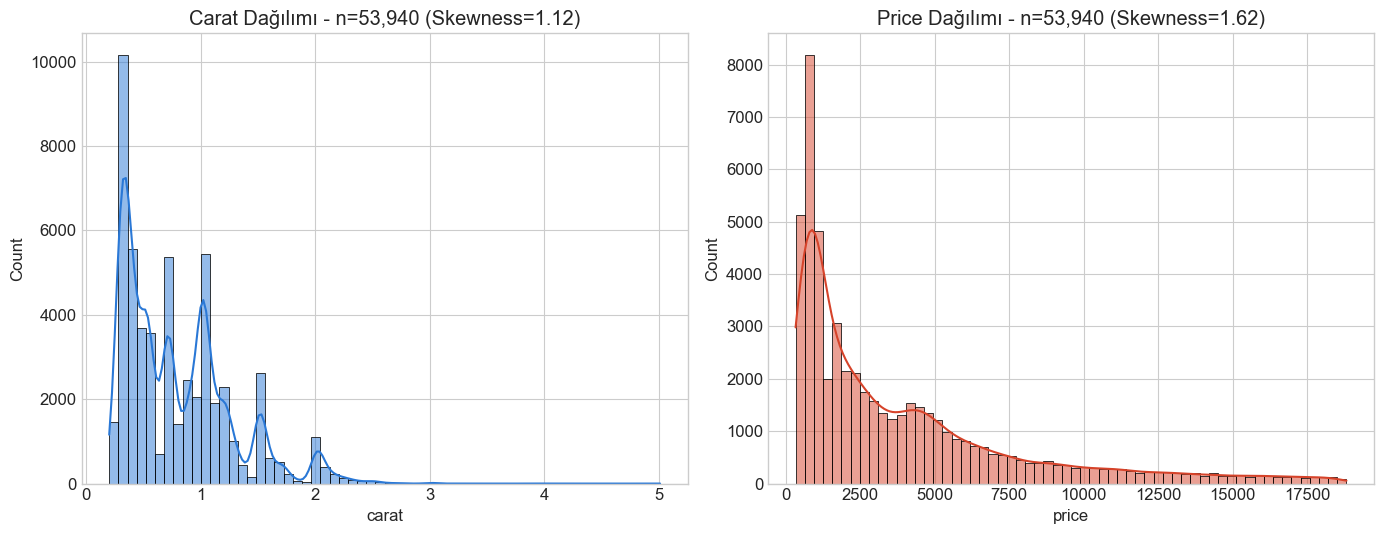

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.histplot(diamonds['carat'], bins=60, kde=True, color='#2a78d6', ax=axes[0])
axes[0].set_title(f"Carat Dağılımı - n={len(diamonds):,} (Skewness={stats.skew(diamonds['carat']):.2f})")

sns.histplot(diamonds['price'], bins=60, kde=True, color='#d6432a', ax=axes[1])
axes[1].set_title(f"Price Dağılımı - n={len(diamonds):,} (Skewness={stats.skew(diamonds['price']):.2f})")

plt.tight_layout()
plt.show()

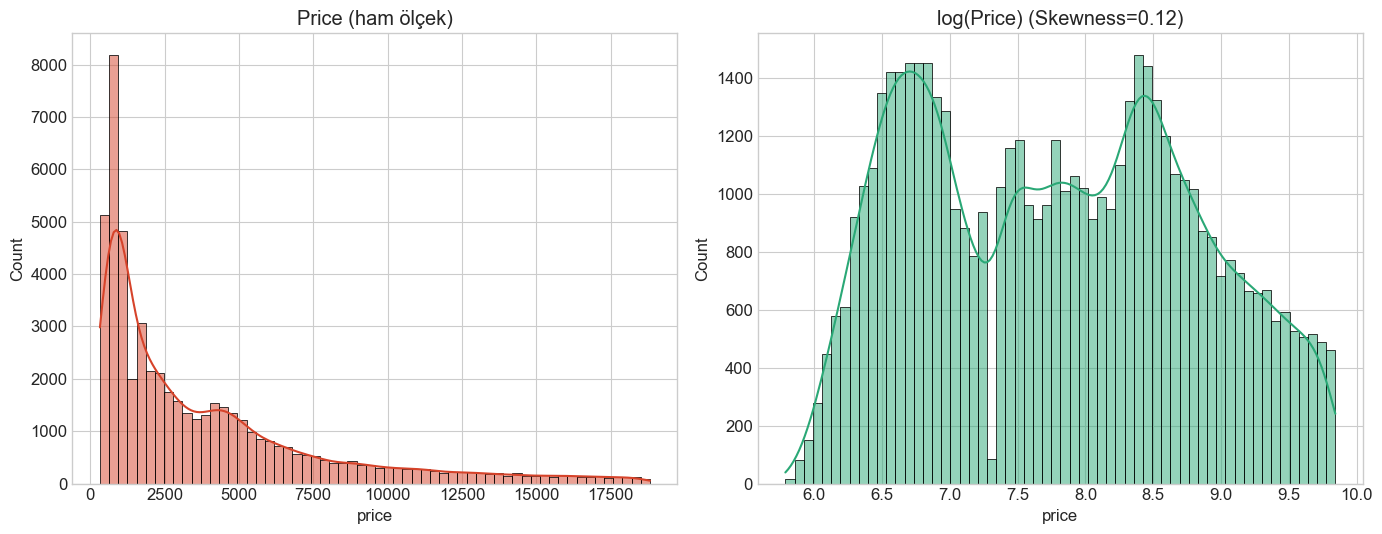

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.histplot(diamonds['price'], bins=60, kde=True, ax=axes[0], color='#d6432a')
axes[0].set_title('Price (ham ölçek)')

log_price = np.log(diamonds['price'])
sns.histplot(log_price, bins=60, kde=True, ax=axes[1], color='#2aa876')
axes[1].set_title(f"log(Price) (Skewness={stats.skew(log_price):.2f})")

plt.tight_layout()
plt.show()

### 🌾 Python 3 — Rug Plot: `penguins['bill_length_mm']` (TAM VERİ, n=333, türe göre)

**Ne yapıyoruz?**
KDE'nin altına rug plot ekleyerek her tekil gözlemin gerçek konumunu gösteriyoruz — üç penguen türünün gaga uzunluğu (`bill_length_mm`) dağılımının ne kadar net ayrıştığını hem yoğunluk hem ham nokta düzeyinde görüyoruz.

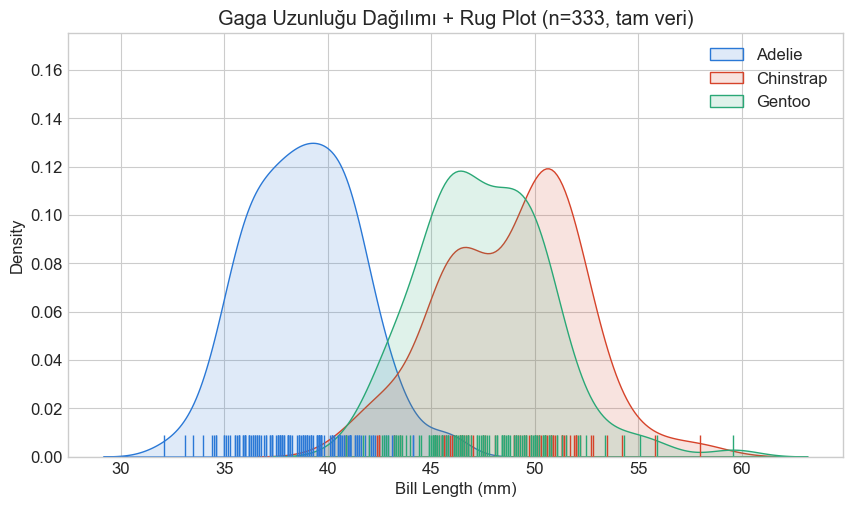

In [5]:
plt.figure(figsize=(10, 5.5))
for species, color in zip(['Adelie', 'Chinstrap', 'Gentoo'], ['#2a78d6', '#d6432a', '#2aa876']):
    subset = penguins.loc[penguins['species'] == species, 'bill_length_mm']
    sns.kdeplot(subset, color=color, label=species, fill=True, alpha=0.15)
    sns.rugplot(subset, color=color, height=0.05)

plt.title(f"Gaga Uzunluğu Dağılımı + Rug Plot (n={len(penguins)}, tam veri)")
plt.xlabel('Bill Length (mm)')
plt.legend()
plt.show()

### 📉 Python 4 — ECDF: `diamonds['price']` (TAM VERİ, `cut` bazında)

**Ne yapıyoruz?**
`price` için kümülatif dağılım fonksiyonunu, `cut` kategorilerine göre üst üste çiziyoruz — hangi kesim kalitesinde fiyatların ne kadarının belirli bir eşiğin altında kaldığını (örn. medyan) doğrudan eksende okuyabiliyoruz.

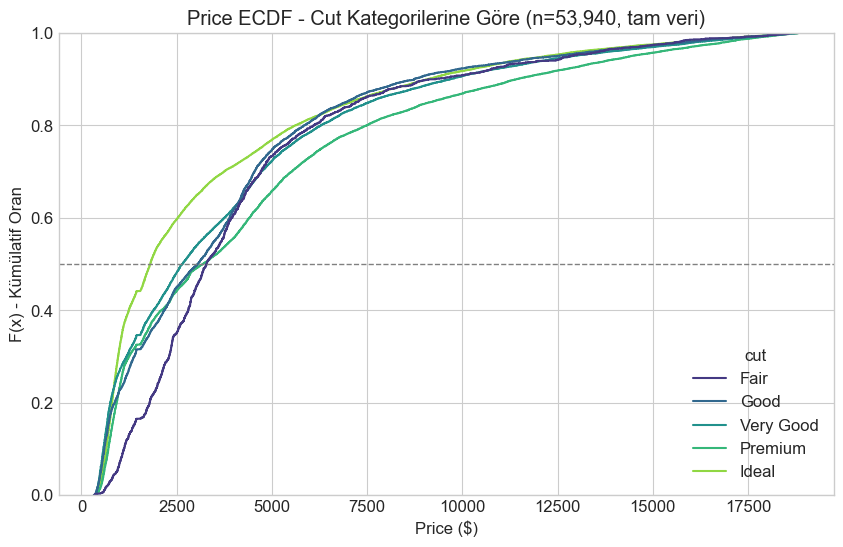

Fair         medyan fiyat (F(x)=0.5 noktasi): $3,282
Good         medyan fiyat (F(x)=0.5 noktasi): $3,050
Very Good    medyan fiyat (F(x)=0.5 noktasi): $2,648
Premium      medyan fiyat (F(x)=0.5 noktasi): $3,185
Ideal        medyan fiyat (F(x)=0.5 noktasi): $1,810


In [6]:
plt.figure(figsize=(10, 6))
sns.ecdfplot(data=diamonds, x='price', hue='cut', palette='viridis')
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.title(f"Price ECDF - Cut Kategorilerine Göre (n={len(diamonds):,}, tam veri)")
plt.xlabel('Price ($)')
plt.ylabel('F(x) - Kümülatif Oran')
plt.show()

for cut_cat in cut_order:
    median_price = diamonds.loc[diamonds['cut'] == cut_cat, 'price'].median()
    print(f"{cut_cat:12s} medyan fiyat (F(x)=0.5 noktasi): ${median_price:,.0f}")

### 📦 Python 5 — Boxplot vs Violin: `titanic['fare']` sınıfa göre (TAM VERİ, n=891)

**Ne yapıyoruz?**
Bilet ücretinin (`fare`) yolcu sınıfına (`class`) göre dağılımını boxplot ve violin ile karşılaştırıyoruz — Bölüm 3.5/3.6'daki "boxplot'un kör noktasını" gerçek veride görüyoruz, ardından 1.5×IQR kuralıyla manuel aykırı değer sayımı yapıyoruz.

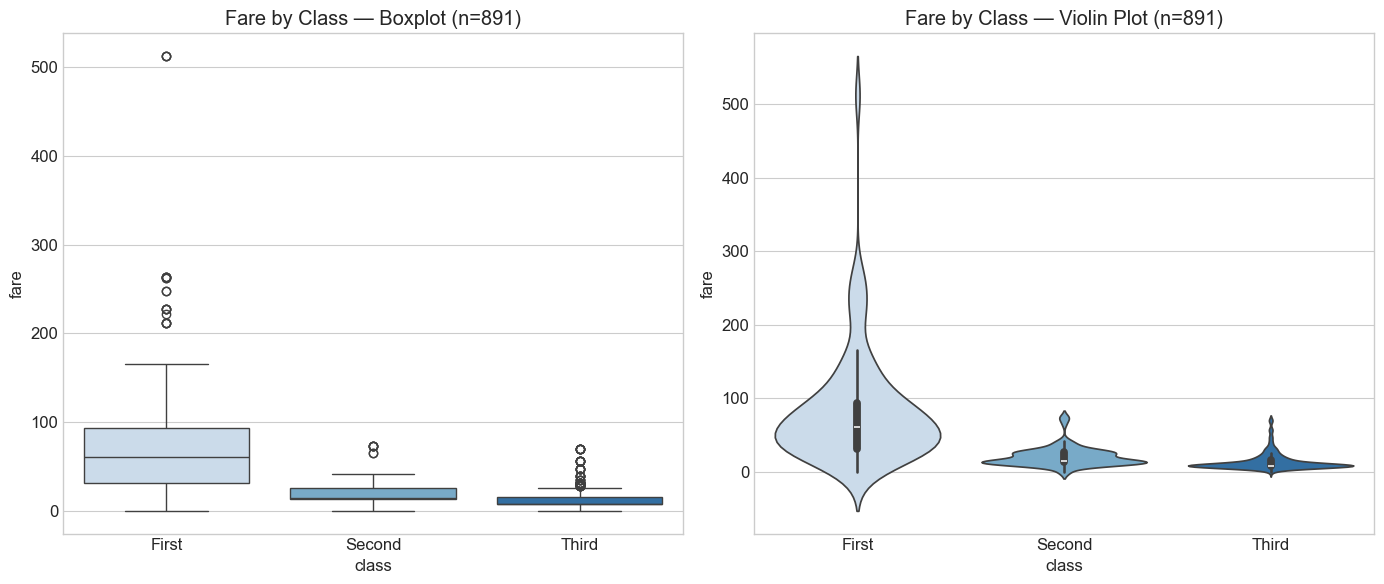

Class      |       Q1       Q3      IQR | Outlier sayisi (1.5xIQR)
------------------------------------------------------------
First      |    30.92    93.50    62.58 |    20 ( 9.3%)
Second     |    13.00    26.00    13.00 |     7 ( 3.8%)
Third      |     7.75    15.50     7.75 |    52 (10.6%)


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.boxplot(data=titanic, x='class', y='fare', hue='class', palette='Blues', legend=False, ax=axes[0])
axes[0].set_title(f'Fare by Class — Boxplot (n={len(titanic)})')

sns.violinplot(data=titanic, x='class', y='fare', hue='class', palette='Blues', legend=False, ax=axes[1])
axes[1].set_title(f'Fare by Class — Violin Plot (n={len(titanic)})')

plt.tight_layout()
plt.show()

print(f"{'Class':10s} | {'Q1':>8s} {'Q3':>8s} {'IQR':>8s} | Outlier sayisi (1.5xIQR)")
print("-" * 60)
for cls in ['First', 'Second', 'Third']:
    subset = titanic.loc[titanic['class'] == cls, 'fare']
    q1, q3 = subset.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((subset < lower) | (subset > upper)).sum()
    print(f"{cls:10s} | {q1:8.2f} {q3:8.2f} {iqr:8.2f} | {n_outliers:5d} ({n_outliers/len(subset)*100:4.1f}%)")

### 🐝 Python 6 — Strip Plot vs Swarm Plot

**Ne yapıyoruz?**
Bölüm 3.7'deki "swarm küçük N'de, strip büyük N'de" kuralını iki farklı veri setinde canlı gösteriyoruz: `penguins` (n=333, swarm rahatça çalışır) ve `titanic['age']` (n=714, swarm burada da çalışır ama gözle görülür şekilde daha yavaş kurulur — bu yüzden pratikte binlerce satırda strip plot tercih edilir).

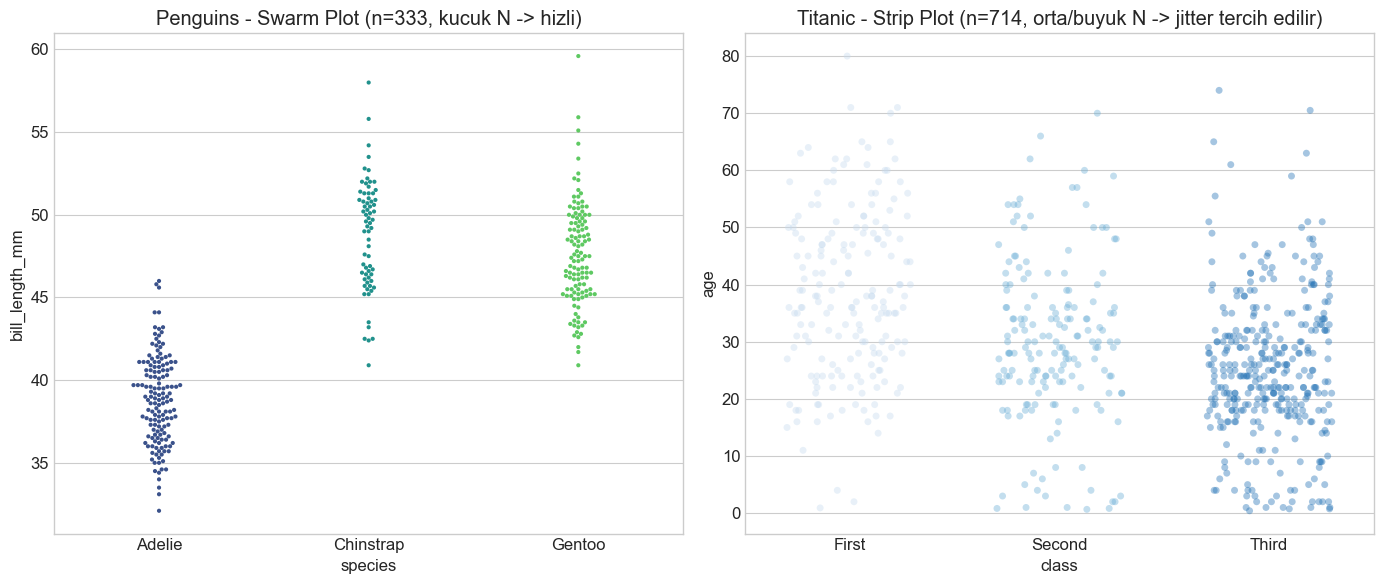

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.swarmplot(data=penguins, x='species', y='bill_length_mm', hue='species', palette='viridis', legend=False, size=3, ax=axes[0])
axes[0].set_title(f'Penguins - Swarm Plot (n={len(penguins)}, kucuk N -> hizli)')

titanic_age = titanic.dropna(subset=['age'])
sns.stripplot(data=titanic_age, x='class', y='age', hue='class', palette='Blues', legend=False, alpha=0.4, jitter=0.3, ax=axes[1])
axes[1].set_title(f'Titanic - Strip Plot (n={len(titanic_age)}, orta/buyuk N -> jitter tercih edilir)')

plt.tight_layout()
plt.show()

---
## 🅱️ Tek Değişkenli Kategorik Grafikler

### 📶 Python 7 — Bar / Count Plot: Titanic Hayatta Kalma Oranı (TAM VERİ, n=891)

**Ne yapıyoruz?**
Sınıf (`class`) ve cinsiyete (`sex`) göre yolcu sayısını (count plot) ve hayatta kalma **oranını** (bar plot, hata çubuklu) çiziyoruz — Bölüm 4.1'deki "y ekseni 0'dan başlamalı" kuralına da dikkat ediyoruz.

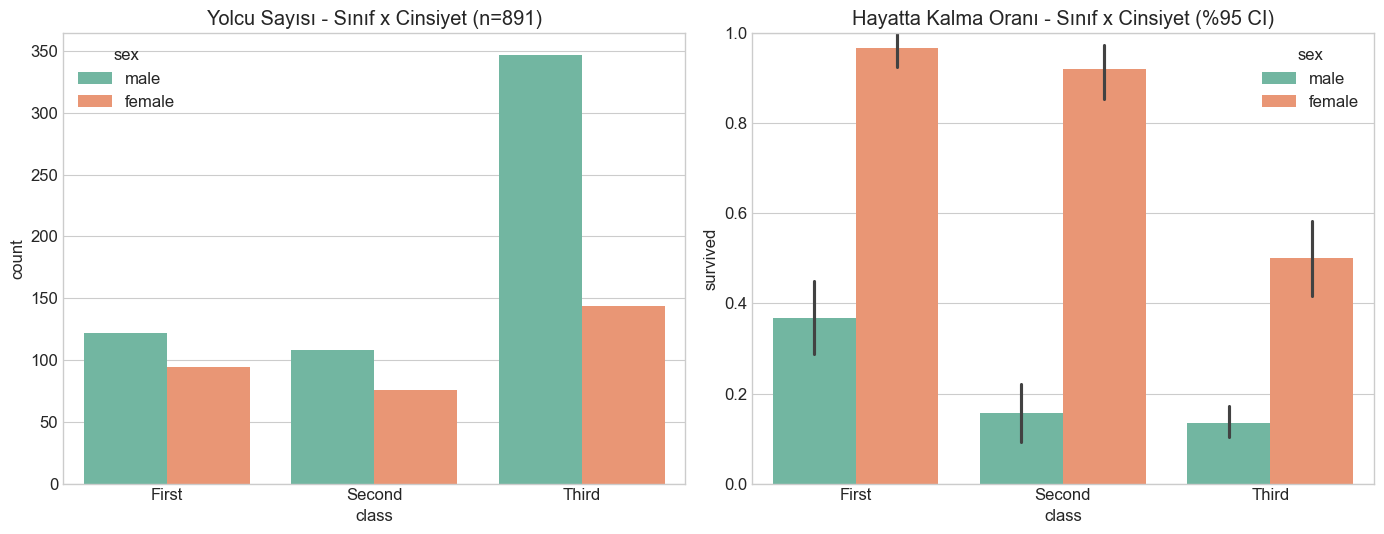

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

sns.countplot(data=titanic, x='class',hue = 'sex', palette='Set2', ax=axes[0])
axes[0].set_title(f'Yolcu Sayısı - Sınıf x Cinsiyet (n={len(titanic)})')

sns.barplot(data=titanic, x='class', y='survived', hue='sex', palette='Set2', errorbar=('ci', 95), ax=axes[1])
axes[1].set_ylim(0, 1)
axes[1].set_title('Hayatta Kalma Oranı - Sınıf x Cinsiyet (%95 CI)')

plt.tight_layout()
plt.show()

---
## © İki Değişkenli (Bivariate) Grafikler

### 📈 Python 8 — Scatter + Trend Çizgisi: `carat` vs `price` (TAM VERİ, n=53.940)

**Ne yapıyoruz?**
53.940 noktayı **hiç örneklem almadan** çiziyoruz — overplotting'i azaltmak için sadece nokta boyutunu/opaklığını küçültüyoruz. Trend çizgisini `ci=None` ile (büyük veride bootstrap CI maliyetli olduğu için) ekliyoruz.

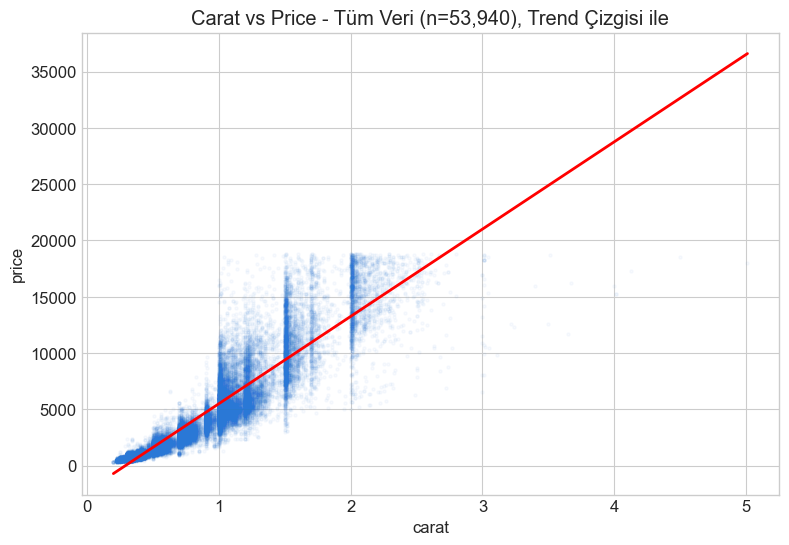

Pearson r = 0.922 | Spearman rho = 0.963
YORUM: alpha=0.03 ile 53.940 nokta ust uste binmeden yogunluk farklarini gostermeye calisiyoruz
ama yine de merkezi bolgede overplotting var -> Python 9'daki hexbin cozumune bak.


In [12]:
plt.figure(figsize=(9, 6))
sns.regplot(data=diamonds, x='carat', y='price', ci=None,
            scatter_kws={'alpha': 0.03, 's': 5, 'color': '#2a78d6'},
            line_kws={'color': 'red', 'linewidth': 2})
plt.title(f'Carat vs Price - Tüm Veri (n={len(diamonds):,}), Trend Çizgisi ile')
plt.show()

pearson_r, _ = stats.pearsonr(diamonds['carat'], diamonds['price'])
spearman_r, _ = stats.spearmanr(diamonds['carat'], diamonds['price'])
print(f"Pearson r = {pearson_r:.3f} | Spearman rho = {spearman_r:.3f}")
print("YORUM: alpha=0.03 ile 53.940 nokta ust uste binmeden yogunluk farklarini gostermeye calisiyoruz")
print("ama yine de merkezi bolgede overplotting var -> Python 9'daki hexbin cozumune bak.")

### 🟧 Python 9 — Hexbin / 2D Histogram: Aynı Veri, Overplotting Çözümü (TAM VERİ)

**Ne yapıyoruz?**
Aynı `carat` vs `price` ilişkisini bu kez **hexbin** ile çiziyoruz — veriyi küçültmeden (tüm 53.940 satır), düzlemi altıgen kutulara bölüp her kutudaki nokta sayısını renkle kodluyoruz (Bölüm 5.4). Log-log ölçekte ilişkinin doğrusallaştığını da gösteriyoruz.

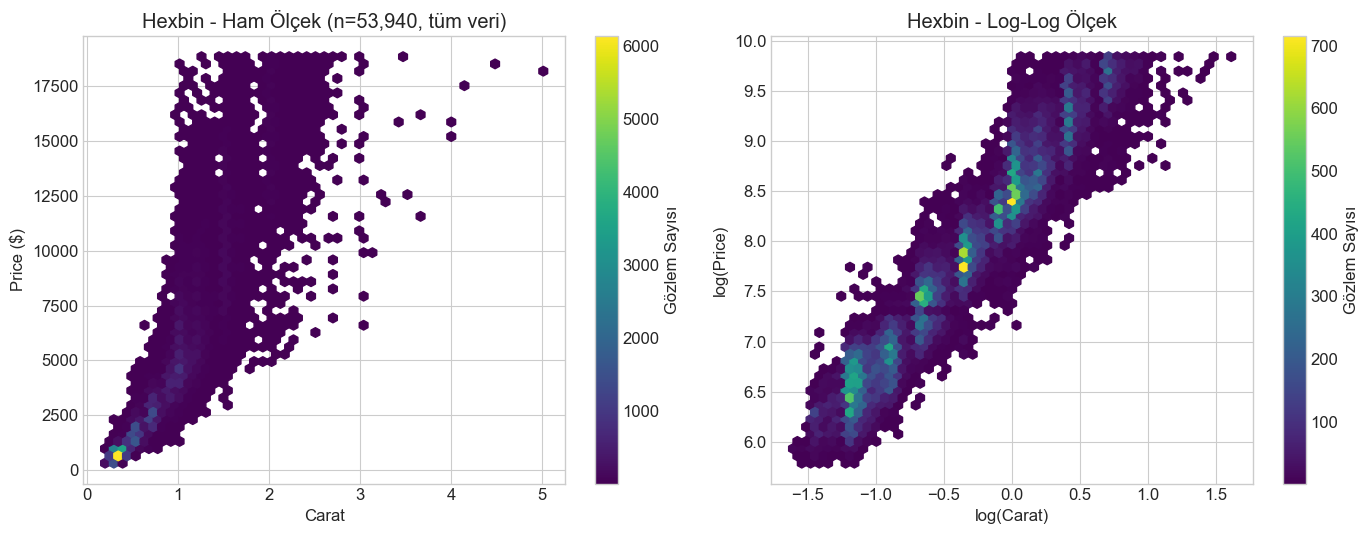

YORUM: Hexbin, hicbir veriyi atmadan (tam n=53.940) yogunluk farklarini nettir gosteriyor —
Python 8'deki scatter'in merkezindeki 'kara delik' etkisi burada kayboluyor.


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

hb1 = axes[0].hexbin(diamonds['carat'], diamonds['price'], gridsize=50, cmap='viridis', mincnt=1)
axes[0].set_title(f'Hexbin - Ham Ölçek (n={len(diamonds):,}, tüm veri)')
axes[0].set_xlabel('Carat'); axes[0].set_ylabel('Price ($)')
fig.colorbar(hb1, ax=axes[0], label='Gözlem Sayısı')

hb2 = axes[1].hexbin(np.log(diamonds['carat']), np.log(diamonds['price']), gridsize=50, cmap='viridis', mincnt=1)
axes[1].set_title('Hexbin - Log-Log Ölçek')
axes[1].set_xlabel('log(Carat)'); axes[1].set_ylabel('log(Price)')
fig.colorbar(hb2, ax=axes[1], label='Gözlem Sayısı')

plt.tight_layout()
plt.show()

print("YORUM: Hexbin, hicbir veriyi atmadan (tam n=53.940) yogunluk farklarini nettir gosteriyor —")
print("Python 8'deki scatter'in merkezindeki 'kara delik' etkisi burada kayboluyor.")

### 🔗 Python 10 — Joint Plot: `penguins` Gaga Uzunluğu vs Derinliği (TAM VERİ, n=333)

**Ne yapıyoruz?**
`sns.jointplot` ile merkeze scatter (türe göre renklendirilmiş), kenarlara marjinal KDE'ler yerleştiriyoruz — Bölüm 5.3'teki "iki değişkenli + tek değişkenli analiz aynı figürde" fikrini uyguluyoruz.

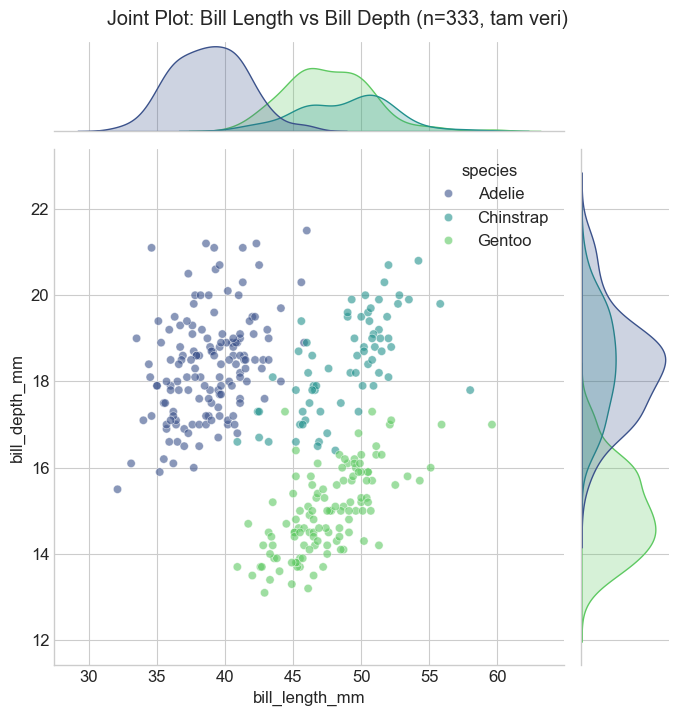

In [14]:
g = sns.jointplot(data=penguins, x='bill_length_mm', y='bill_depth_mm', hue='species',
                   palette='viridis', height=7, alpha=0.6)
g.fig.suptitle(f'Joint Plot: Bill Length vs Bill Depth (n={len(penguins)}, tam veri)', y=1.02)
plt.show()

### 🌀 Python 11 — 2D KDE (Contour): Aynı Penguen Verisi (TAM VERİ)

**Ne yapıyoruz?**
Joint plot'taki scatter'ı, üç tür için ayrı ayrı **2 boyutlu yoğunluk konturlarıyla** değiştiriyoruz — türlerin gaga uzunluğu/derinliği uzayında ne kadar net ayrıştığını (ya da örtüştüğünü) gösteriyoruz.

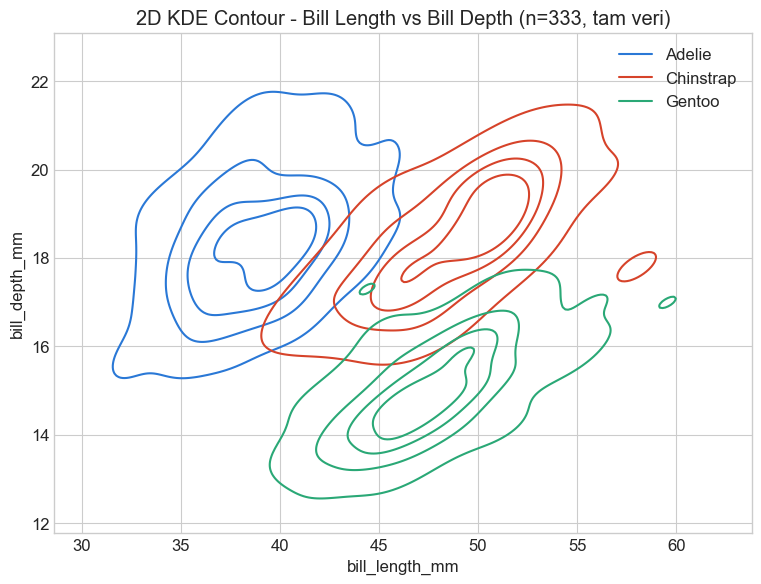

In [15]:
from matplotlib.lines import Line2D

plt.figure(figsize=(9, 6.5))
species_colors = {'Adelie': '#2a78d6', 'Chinstrap': '#d6432a', 'Gentoo': '#2aa876'}
for species, color in species_colors.items():
    subset = penguins[penguins['species'] == species]
    sns.kdeplot(data=subset, x='bill_length_mm', y='bill_depth_mm', color=color,
                levels=5, linewidths=1.5)

# kdeplot kontur cizgileri otomatik legend elemani uretmiyor -> proxy handle ile elle ekliyoruz
legend_handles = [Line2D([0], [0], color=c, label=s) for s, c in species_colors.items()]
plt.legend(handles=legend_handles)
plt.title(f'2D KDE Contour - Bill Length vs Bill Depth (n={len(penguins)}, tam veri)')
plt.show()

### 🟥 Python 12 — Correlation Heatmap: `diamonds` Sayısal Değişkenleri (TAM VERİ)

**Ne yapıyoruz?**
`carat, depth, table, price, x, y, z` sütunlarının Pearson korelasyon matrisini hesaplayıp heatmap ile görselleştiriyoruz.

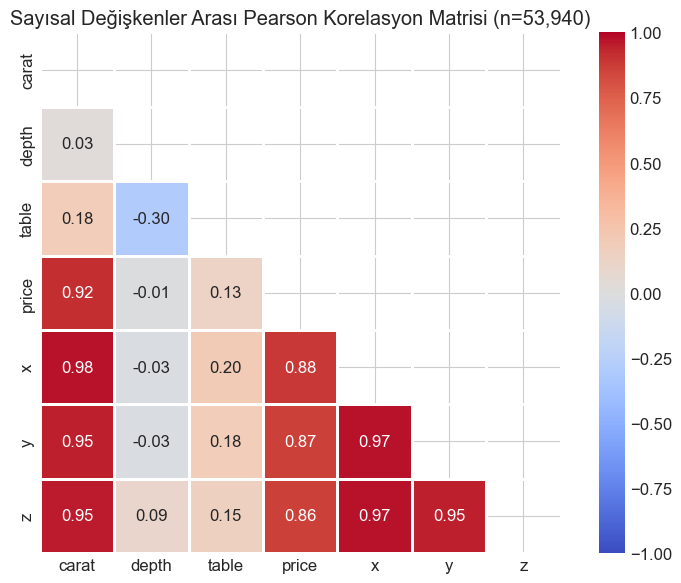

YORUM: carat, x, y, z birbiriyle neredeyse mukemmel korele -> multicollinearity sinyali
(bkz. regression_diagnostics.ipynb, Bolum 7 - VIF). depth/table, price ile zayif korele.


In [18]:
numeric_cols = ['carat', 'depth', 'table', 'price', 'x', 'y', 'z']
corr_matrix = diamonds[numeric_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, linewidths=1, square=True)
plt.title(f'Sayısal Değişkenler Arası Pearson Korelasyon Matrisi (n={len(diamonds):,})')
plt.tight_layout()
plt.show()

print("YORUM: carat, x, y, z birbiriyle neredeyse mukemmel korele -> multicollinearity sinyali")
print("(bkz. regression_diagnostics.ipynb, Bolum 7 - VIF). depth/table, price ile zayif korele.")

---
## Ⓓ Çok Değişkenli (Multivariate) Grafikler

### 🕸️ Python 13 — Pairplot: `penguins` (TAM VERİ, n=333 — örneklem YOK)

**Ne yapıyoruz?**
Penguins küçük bir veri seti olduğu için **hiç örneklem almadan**, 333 satırın tamamıyla 4 sayısal değişkenin ($k=4 \to 16$ alt grafik) pairplot'unu çiziyoruz, türe göre renklendiriyoruz.

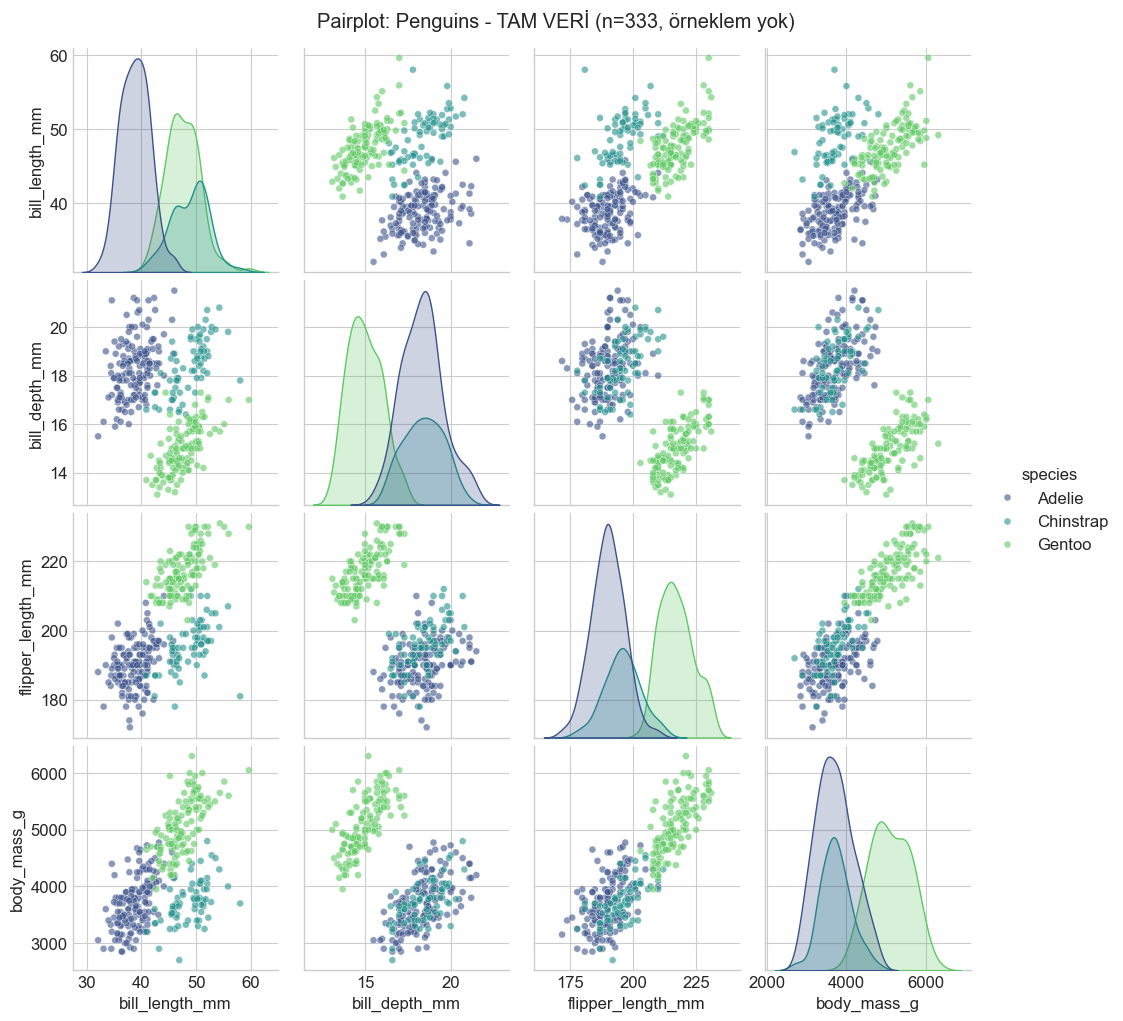

In [19]:
g = sns.pairplot(penguins, vars=['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g'],
                  hue='species', palette='viridis', diag_kind='kde', plot_kws={'alpha': 0.6, 's': 25})
g.fig.suptitle(f'Pairplot: Penguins - TAM VERİ (n={len(penguins)}, örneklem yok)', y=1.02)
plt.show()

### 🕸️ Python 14 — Pairplot: `diamonds` (Büyük Örneklem, n=8.000)

**Ne yapıyoruz?**
53.940 satırlık `diamonds` için pairplot maliyeti gerçekten yüksektir ($O(n)$ nokta çizimi $\times k^2$ panel) — burada **performans için gerekli olan minimum ölçüde** büyük bir örneklem (n=8.000, önceki denememizin 8 katı) kullanıyoruz ve bunu neden yaptığımızı açıkça belirtiyoruz.

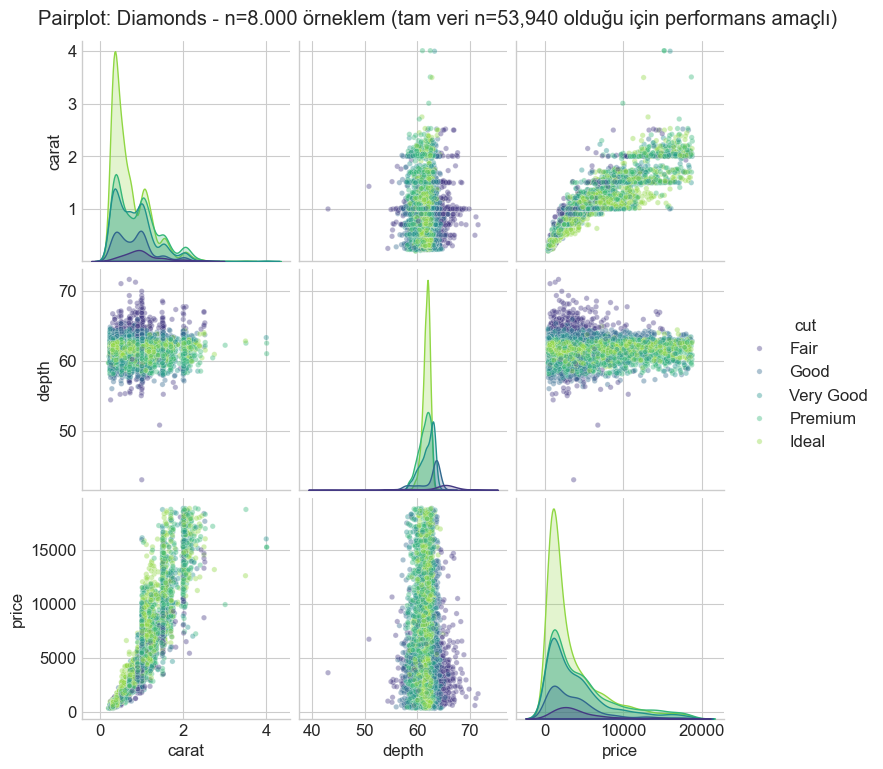

In [20]:
sample_diamonds = diamonds.sample(8000, random_state=42)

g = sns.pairplot(sample_diamonds, vars=['carat', 'depth', 'price'], hue='cut',
                  palette='viridis', diag_kind='kde', plot_kws={'alpha': 0.4, 's': 15})
g.fig.suptitle(f'Pairplot: Diamonds - n=8.000 örneklem (tam veri n={len(diamonds):,} olduğu için performans amaçlı)', y=1.02)
plt.show()

### 🔲 Python 15 — FacetGrid / Small Multiples: Titanic Hayatta Kalma (TAM VERİ)

**Ne yapıyoruz?**
Bölüm 6.2'deki fikri uyguluyoruz — sınıf x cinsiyet kombinasyonlarını `hue` ile tek grafikte toplamak yerine, her kombinasyon için **ayrı bir panel** çiziyoruz (`sns.catplot`, `kind='bar'`).

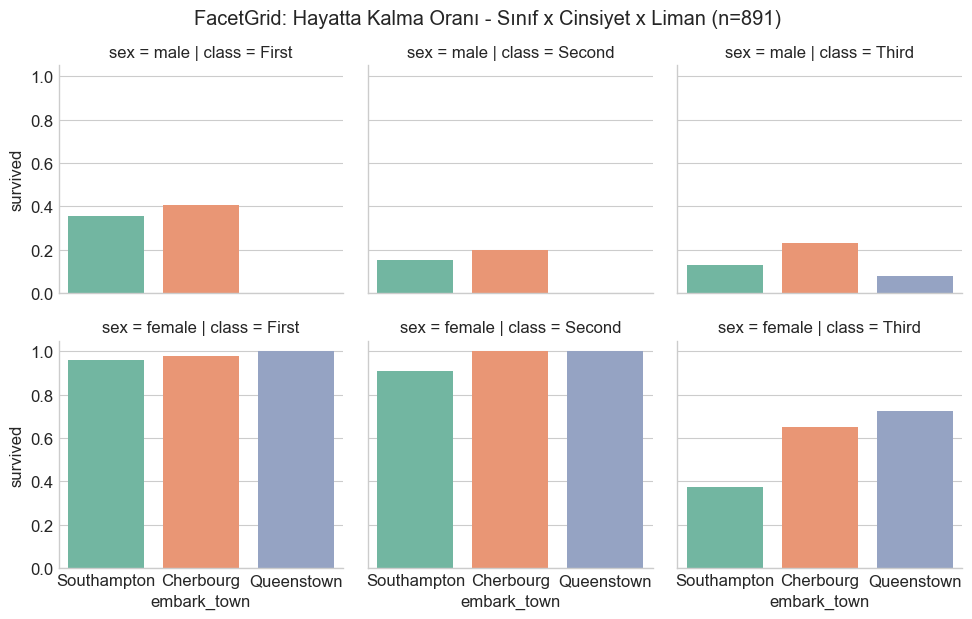

In [21]:
g = sns.catplot(data=titanic, x='embark_town', y='survived', hue='embark_town', col='class', row='sex',
                 kind='bar', palette='Set2', legend=False, errorbar=None, height=3, aspect=1.1)
g.fig.suptitle(f'FacetGrid: Hayatta Kalma Oranı - Sınıf x Cinsiyet x Liman (n={len(titanic)})', y=1.03)
plt.show()

### 🌡️ Python 16 — Clustermap: `diamonds` Korelasyon Matrisi + Hiyerarşik Kümeleme

**Ne yapıyoruz?**
Python 12'deki heatmap'e hiyerarşik kümeleme ekliyoruz — `sns.clustermap`, benzer korelasyon örüntüsüne sahip değişkenleri otomatik olarak yan yana getirip bir dendrogram çiziyor (Bölüm 6.3).

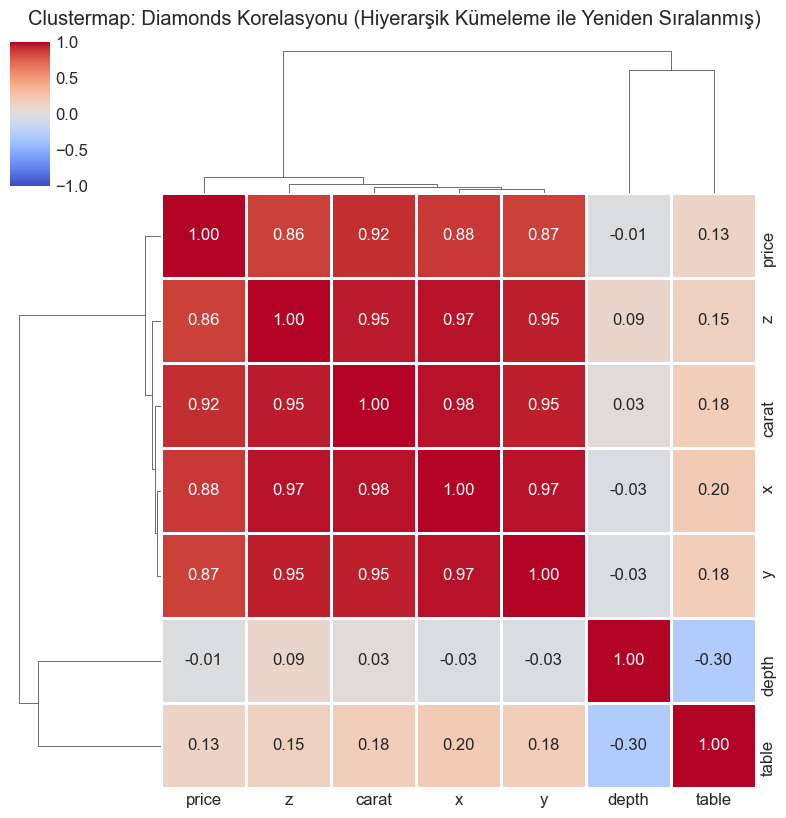

YORUM: Dendrogram, 'carat-x-y-z' grubunun ve 'depth-table' grubunun birbirinden ayri
kumelendigini gosteriyor -> bu ayrim, Python 12'deki duz siradaki heatmap'te bu kadar net degildi.


In [22]:
g = sns.clustermap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1,
                    figsize=(8, 8), linewidths=1)
g.fig.suptitle('Clustermap: Diamonds Korelasyonu (Hiyerarşik Kümeleme ile Yeniden Sıralanmış)', y=1.02)
plt.show()

print("YORUM: Dendrogram, 'carat-x-y-z' grubunun ve 'depth-table' grubunun birbirinden ayri")
print("kumelendigini gosteriyor -> bu ayrim, Python 12'deki duz siradaki heatmap'te bu kadar net degildi.")

### 🫧 Python 17 — Bubble Chart: `penguins` (TAM VERİ, 4 Boyut Tek Grafikte)

**Ne yapıyoruz?**
`bill_length_mm` (x), `body_mass_g` (y), `flipper_length_mm` (marker boyutu = 3. boyut), `species` (renk = 4. boyut) — 4 değişkeni tek 2D grafikte gösteriyoruz (Bölüm 6.4).

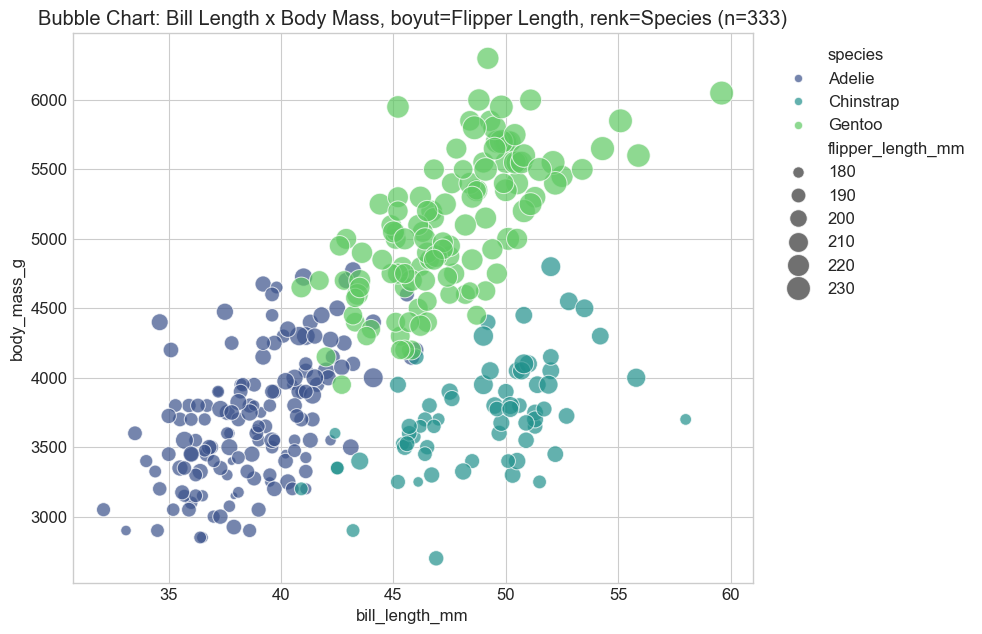

In [23]:
plt.figure(figsize=(10, 6.5))
sns.scatterplot(data=penguins, x='bill_length_mm', y='body_mass_g',
                 size='flipper_length_mm', hue='species', sizes=(30, 300),
                 palette='viridis', alpha=0.7)
plt.title(f'Bubble Chart: Bill Length x Body Mass, boyut=Flipper Length, renk=Species (n={len(penguins)})')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

### 〰️ Python 18 — Parallel Coordinates: `penguins` (TAM VERİ)

**Ne yapıyoruz?**
4 sayısal değişkeni 0-1 aralığına ölçekleyip (min-max normalization — eksenler karşılaştırılabilir olsun diye), her penguen gözlemini tüm eksenleri kesen tek bir çizgi olarak çiziyoruz. Türe göre renklendirip **çizgi demetlerinin** (bundles) ne kadar net ayrıştığını görüyoruz (Bölüm 6.5).

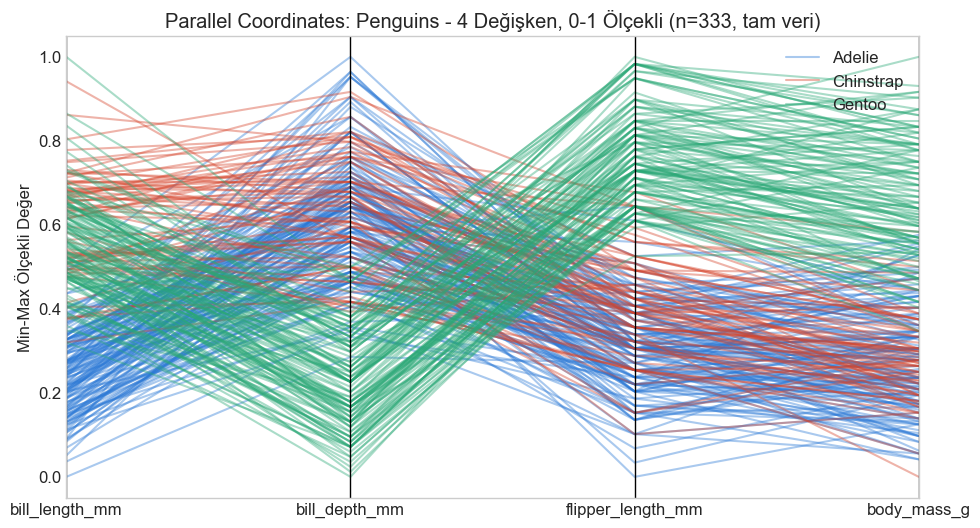

YORUM: Gentoo turu 'flipper_length_mm' ve 'body_mass_g' eksenlerinde net bir ust bant
olusturuyor -> bu iki degisken, turleri ayirt etmede en guclu ikili.


In [24]:
num_cols_pc = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
penguins_scaled = penguins.copy()
for c in num_cols_pc:
    penguins_scaled[c] = (penguins_scaled[c] - penguins_scaled[c].min()) / (penguins_scaled[c].max() - penguins_scaled[c].min())

plt.figure(figsize=(11, 6))
parallel_coordinates(penguins_scaled[num_cols_pc + ['species']], class_column='species',
                      color=['#2a78d6', '#d6432a', '#2aa876'], alpha=0.4)
plt.title(f'Parallel Coordinates: Penguins - 4 Değişken, 0-1 Ölçekli (n={len(penguins)}, tam veri)')
plt.ylabel('Min-Max Ölçekli Değer')
plt.show()

print("YORUM: Gentoo turu 'flipper_length_mm' ve 'body_mass_g' eksenlerinde net bir ust bant")
print("olusturuyor -> bu iki degisken, turleri ayirt etmede en guclu ikili.")

---
# 📊 R Uygulaması: ggplot2 Ailesi (ggplot2, corrplot, GGally, ggbeeswarm, ggExtra)

**Yeni R kavramları:**
- `diamonds`, `ggplot2` paketine **gömülü** gelir (`data(diamonds)`).
- `penguins`, CRAN'daki `palmerpenguins` paketine gömülü gelir (`data(penguins, package = "palmerpenguins")`) — Allison Horst'un R paketi, Python tarafındaki `seaborn` sürümüyle aynı kaynak veriye dayanır.
- `titanic` için R'da hazır, satır-satır aynı yapıda bir paket bulunmadığından, Python'da temizlediğimiz `titanic_r` veri çerçevesini `%%R -i titanic_r` ile aktarıyoruz.

rpy2'de bir R hücresi çalıştığında tanımlanan değişkenler (örn. `diamonds`, `penguins`, `titanic_r`), aynı notebook oturumu boyunca **sonraki tüm `%%R` hücrelerinde** erişilebilir kalır — bu yüzden aşağıdaki hücrelerde tekrar `-i` yazmıyoruz.

In [25]:
%load_ext rpy2.ipython

Error importing in API mode: ImportError("dlopen(/opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so, 0x0002): Library not loaded: /Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib\n  Referenced from: <2F94BB47-26EE-3EB3-85C5-1EA8A83C71AB> /opt/anaconda3/lib/python3.13/site-packages/_rinterface_cffi_api.abi3.so\n  Reason: tried: '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/System/Volumes/Preboot/Cryptexes/OS/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file), '/Library/Frameworks/R.framework/Versions/4.5-arm64/Resources/lib/libRblas.dylib' (no such file)")
Trying to import in ABI mode.


In [29]:
%%R -i titanic_r
#install.packages(c("palmerpenguins","GGally","ggbeeswarm","ggExtra","gridExtra","corrplot","hexbin")) #calistirmasi gerekebilir
library(ggplot2)
library(palmerpenguins)

data(diamonds)                               # ggplot2'ye gomulu
data(penguins, package = "palmerpenguins")   # palmerpenguins paketine gomulu
penguins <- na.omit(penguins)

cat("R hazir - diamonds:", nrow(diamonds), "| penguins:", nrow(penguins), "| titanic_r:", nrow(titanic_r), "\n")

R hazir - diamonds: 53940 | penguins: 333 | titanic_r: 712 


## 🅰️ R — Tek Değişkenli Sayısal Dağılım Grafikleri

### 📊 R 1 — Histogram + Density + Rug + ECDF (2x2 Grid, `diamonds$price`, TAM VERİ)

**Ne yapıyoruz?**
Bölüm 3'teki 4 dağılım grafiğini (`geom_histogram`, `geom_density`, `geom_density`+`geom_rug`, `stat_ecdf`) tek bir 2x2 grid'de topluyoruz — Python 2-4'ün R karşılığı, tamamı `price`'ın tüm 53.940 gözlemiyle.

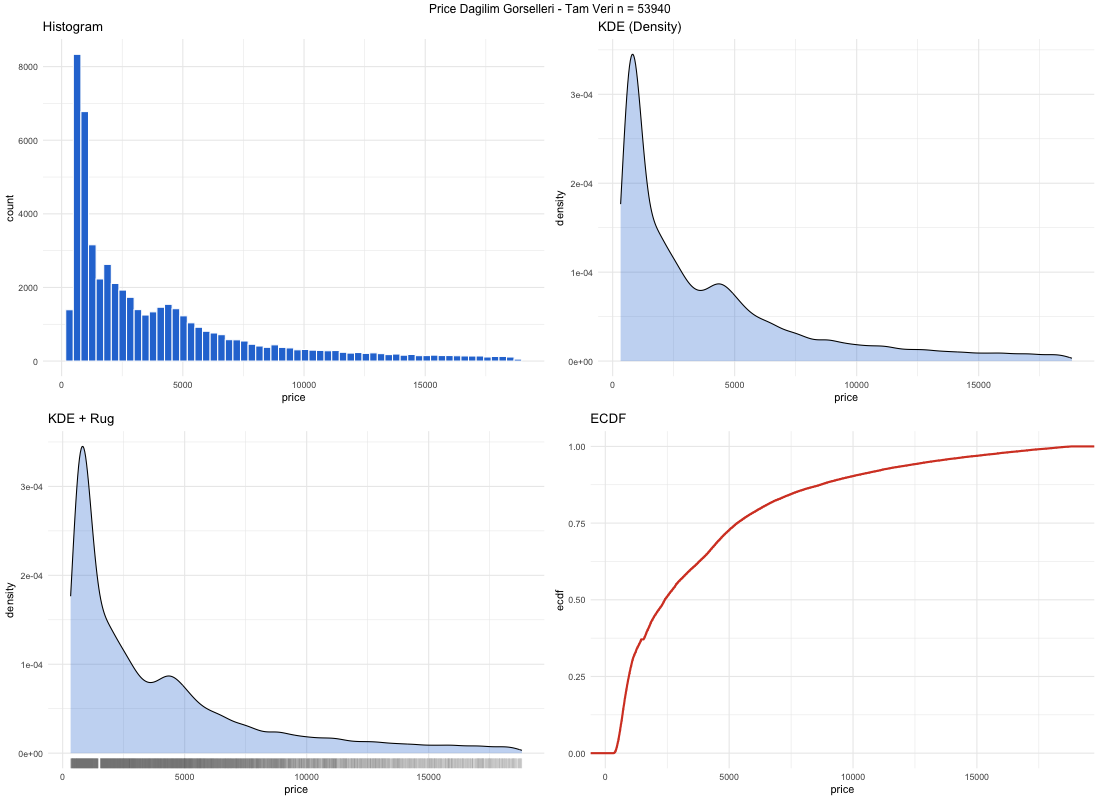

In [30]:
%%R -w 1100 -h 800
library(gridExtra)

p1 <- ggplot(diamonds, aes(x = price)) +
  geom_histogram(bins = 60, fill = "#2a78d6", color = "white") +
  theme_minimal() + ggtitle("Histogram")

p2 <- ggplot(diamonds, aes(x = price)) +
  geom_density(fill = "#2a78d6", alpha = 0.3) +
  theme_minimal() + ggtitle("KDE (Density)")

p3 <- ggplot(diamonds, aes(x = price)) +
  geom_density(fill = "#2a78d6", alpha = 0.3) +
  geom_rug(alpha = 0.02) +
  theme_minimal() + ggtitle("KDE + Rug")

p4 <- ggplot(diamonds, aes(x = price)) +
  stat_ecdf(color = "#d6432a", linewidth = 1) +
  theme_minimal() + ggtitle("ECDF")

grid.arrange(p1, p2, p3, p4, ncol = 2,
             top = paste("Price Dagilim Gorselleri - Tam Veri n =", nrow(diamonds)))

### 📦 R 2 — Boxplot vs Violin: `titanic_r$fare` sınıfa göre (TAM VERİ)

**Ne yapıyoruz?**
Python 5'in R karşılığı: `geom_boxplot` ve `geom_violin` ile bilet ücretini sınıfa göre karşılaştırıyoruz.

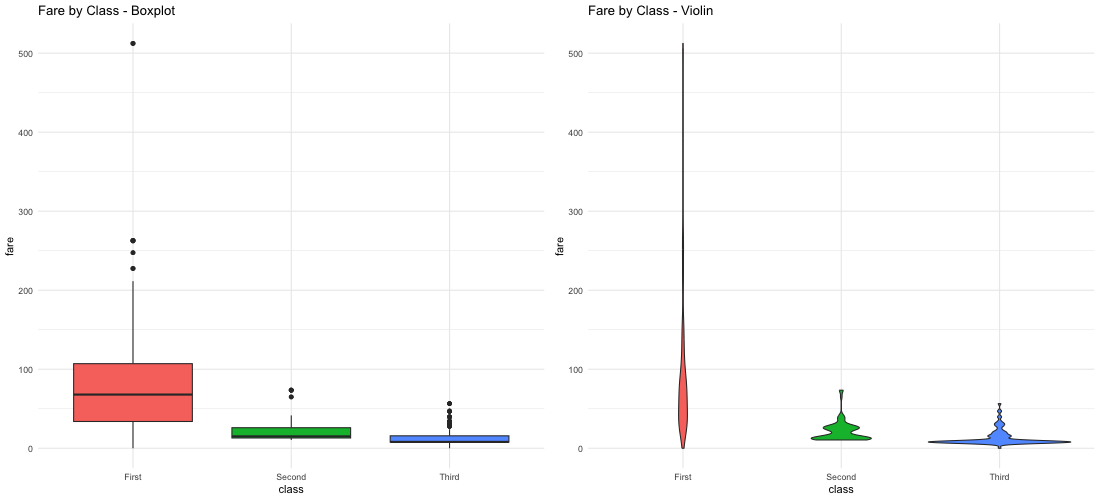

In [31]:
%%R -w 1100 -h 500
p1 <- ggplot(titanic_r, aes(x = class, y = fare, fill = class)) +
  geom_boxplot() + theme_minimal() + theme(legend.position = "none") +
  ggtitle("Fare by Class - Boxplot")

p2 <- ggplot(titanic_r, aes(x = class, y = fare, fill = class)) +
  geom_violin() + theme_minimal() + theme(legend.position = "none") +
  ggtitle("Fare by Class - Violin")

grid.arrange(p1, p2, ncol = 2)

### 🐝 R 3 — Strip (Jitter) vs Swarm (Beeswarm): `penguins$bill_length_mm` (TAM VERİ)

**Yeni R kavramı:** `ggbeeswarm::geom_beeswarm()`, Python'daki `swarmplot`'un R karşılığı — noktaları örtüşmeyecek şekilde diziyor.

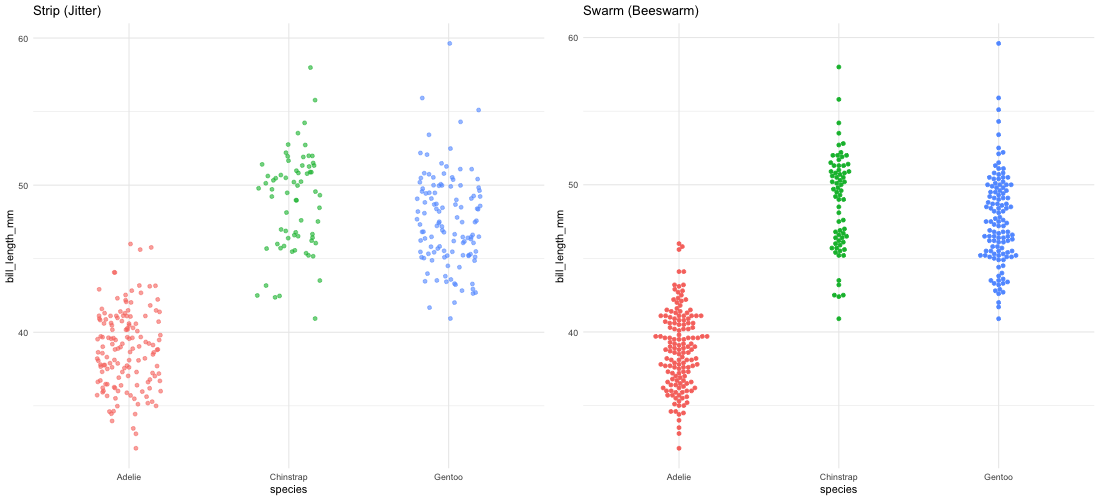

In [32]:
%%R -w 1100 -h 500
library(ggbeeswarm)

p1 <- ggplot(penguins, aes(x = species, y = bill_length_mm, color = species)) +
  geom_jitter(width = 0.2, alpha = 0.6) + theme_minimal() + theme(legend.position = "none") +
  ggtitle("Strip (Jitter)")

p2 <- ggplot(penguins, aes(x = species, y = bill_length_mm, color = species)) +
  geom_beeswarm(size = 1.5) + theme_minimal() + theme(legend.position = "none") +
  ggtitle("Swarm (Beeswarm)")

grid.arrange(p1, p2, ncol = 2)

## 🅱️ R — Tek Değişkenli Kategorik Grafikler

### 📶 R 4 — Bar / Count Plot: Titanic (TAM VERİ)

**Ne yapıyoruz?**
Python 7'nin R karşılığı: `geom_bar` ile sayım, `stat_summary(fun = mean, geom = "bar")` ile hayatta kalma oranı.

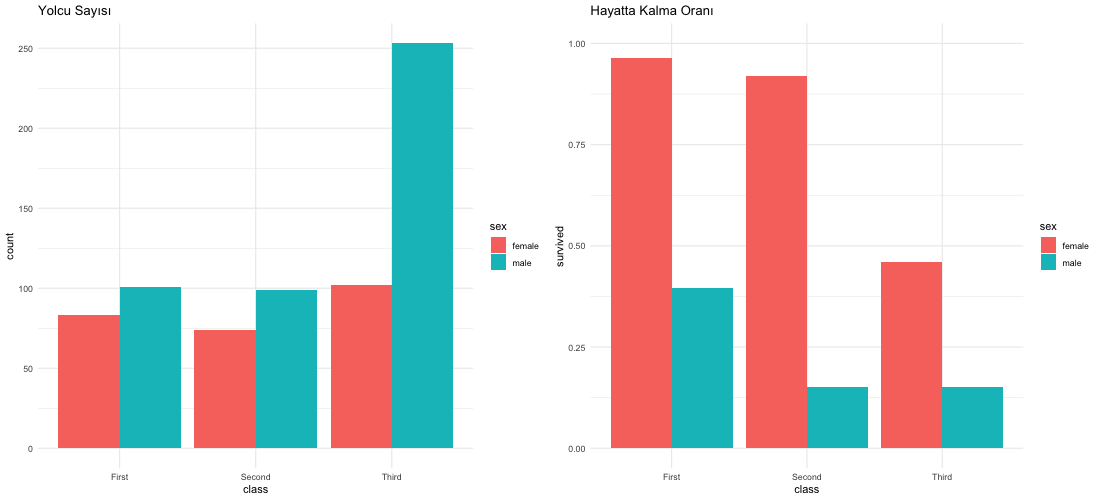

In [33]:
%%R -w 1100 -h 500
p1 <- ggplot(titanic_r, aes(x = class, fill = sex)) +
  geom_bar(position = "dodge") + theme_minimal() + ggtitle("Yolcu Sayısı")

p2 <- ggplot(titanic_r, aes(x = class, y = survived, fill = sex)) +
  stat_summary(fun = mean, geom = "bar", position = "dodge") +
  ylim(0, 1) + theme_minimal() + ggtitle("Hayatta Kalma Oranı")

grid.arrange(p1, p2, ncol = 2)

## © R — İki Değişkenli (Bivariate) Grafikler

### 📈 R 5 — Scatter + Trend Çizgisi: `carat` vs `price` (TAM VERİ)

**Ne yapıyoruz?**
Python 8'in R karşılığı — tüm 53.940 noktayı düşük opaklıkla çiziyoruz, `geom_smooth(method="lm")` ile trend çizgisi ekliyoruz.

`geom_smooth()` using formula = 'y ~ x'


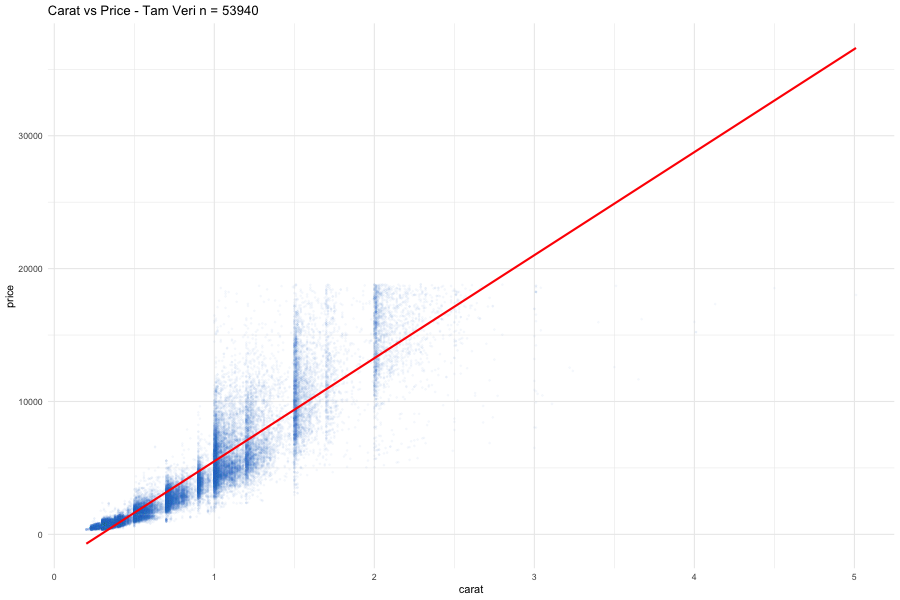

In [34]:
%%R -w 900 -h 600
ggplot(diamonds, aes(x = carat, y = price)) +
  geom_point(alpha = 0.03, size = 0.5, color = "#2a78d6") +
  geom_smooth(method = "lm", color = "red", se = FALSE) +
  theme_minimal() +
  ggtitle(paste("Carat vs Price - Tam Veri n =", nrow(diamonds)))

### 🟧 R 6 — Hexbin: Aynı Veri, Overplotting Çözümü (TAM VERİ)

**Yeni R kavramı:** `geom_hex()` — `hexbin` paketine ihtiyaç duyar, Python'daki `plt.hexbin`'in R karşılığı.

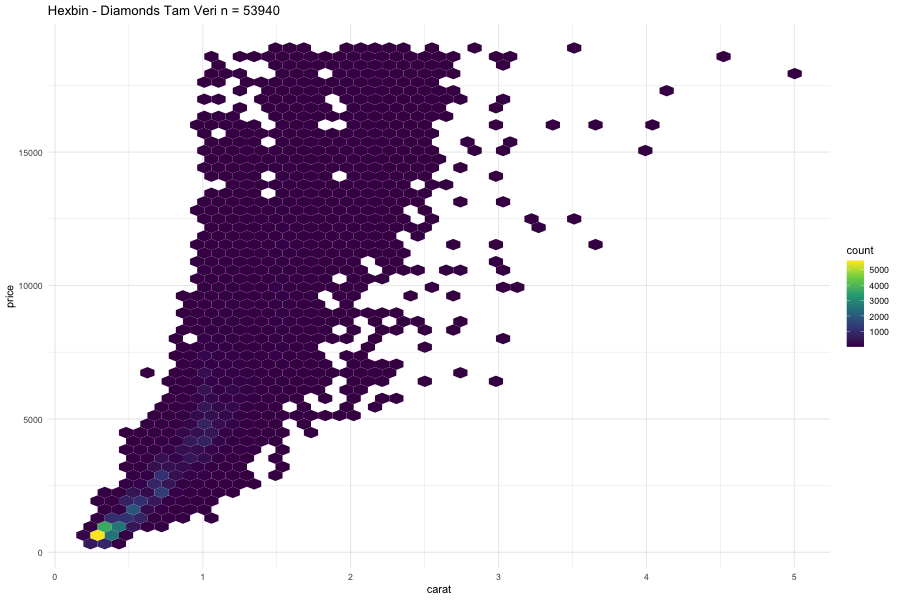

In [35]:
%%R -w 900 -h 600
ggplot(diamonds, aes(x = carat, y = price)) +
  geom_hex(bins = 50) +
  scale_fill_viridis_c() +
  theme_minimal() +
  ggtitle(paste("Hexbin - Diamonds Tam Veri n =", nrow(diamonds)))

### 🔗 R 7 — Joint Plot Karşılığı: `ggExtra::ggMarginal`

**Yeni R kavramı:** `ggMarginal()`, sıradan bir ggplot nesnesinin kenarlarına marjinal yoğunluk grafikleri ekleyerek Python'daki `sns.jointplot`'un aynısını üretir.

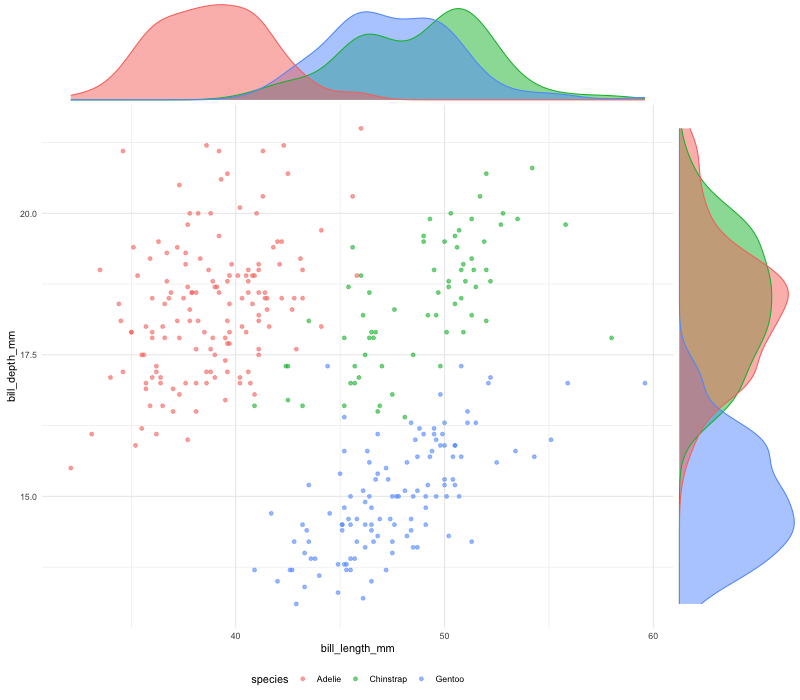

In [36]:
%%R -w 800 -h 700
library(ggExtra)

p <- ggplot(penguins, aes(x = bill_length_mm, y = bill_depth_mm, color = species)) +
  geom_point(alpha = 0.6) + theme_minimal() + theme(legend.position = "bottom")

ggMarginal(p, type = "density", groupColour = TRUE, groupFill = TRUE)

### 🌀 R 8 — 2D KDE (Contour): Aynı Penguen Verisi

**Ne yapıyoruz?**
`geom_density_2d()` ile Python 11'in aynısını üretiyoruz.

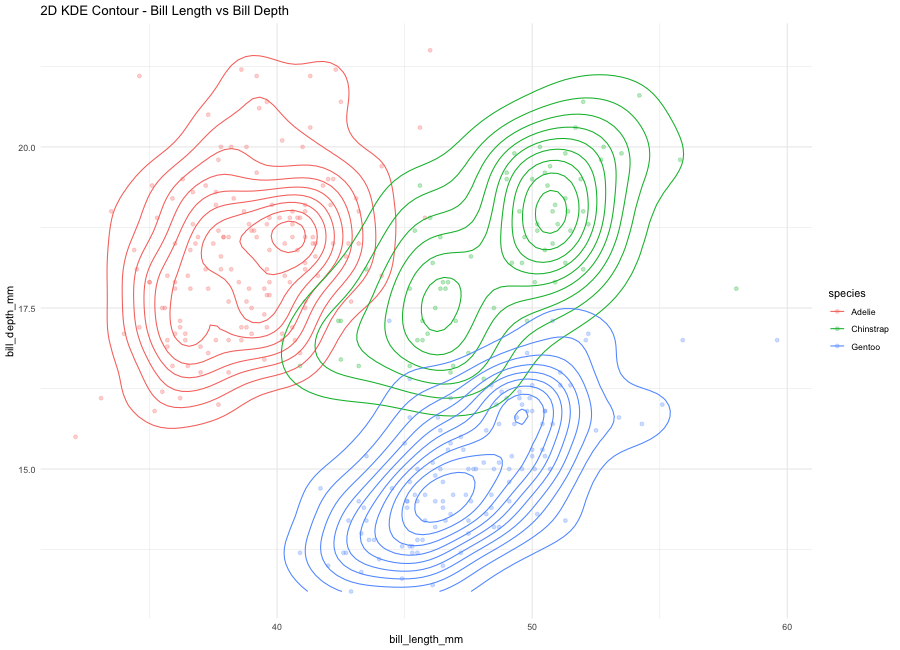

In [37]:
%%R -w 900 -h 650
ggplot(penguins, aes(x = bill_length_mm, y = bill_depth_mm, color = species)) +
  geom_point(alpha = 0.3) +
  geom_density_2d() +
  theme_minimal() +
  ggtitle("2D KDE Contour - Bill Length vs Bill Depth")

### 🟥 R 9 — Correlation Heatmap (`corrplot`)

**Ne yapıyoruz?**
`covariance_correlation.ipynb`'de tanıdığımız `corrplot` paketini `diamonds`'ın sayısal sütunlarına uyguluyoruz — Python 12'nin R karşılığı.

corrplot 0.95 loaded


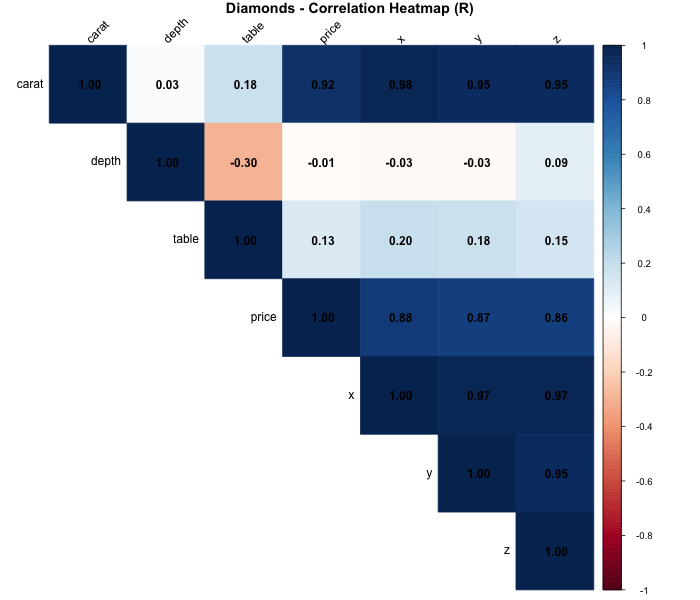

In [38]:
%%R -w 700 -h 600
library(corrplot)

num_cols_r <- diamonds[, c("carat", "depth", "table", "price", "x", "y", "z")]
corr_mat_r <- cor(num_cols_r)

corrplot(corr_mat_r, method = "color", type = "upper",
         addCoef.col = "black", tl.col = "black", tl.srt = 45,
         title = "Diamonds - Correlation Heatmap (R)", mar = c(0, 0, 1, 0))

## Ⓓ R — Çok Değişkenli (Multivariate) Grafikler

### 🕸️ R 10 — Pairplot Karşılığı: `GGally::ggpairs` (`penguins`, TAM VERİ)

**Ne yapıyoruz?**
Python 13'ün R karşılığı — 333 satırın tamamıyla, örneklem almadan.

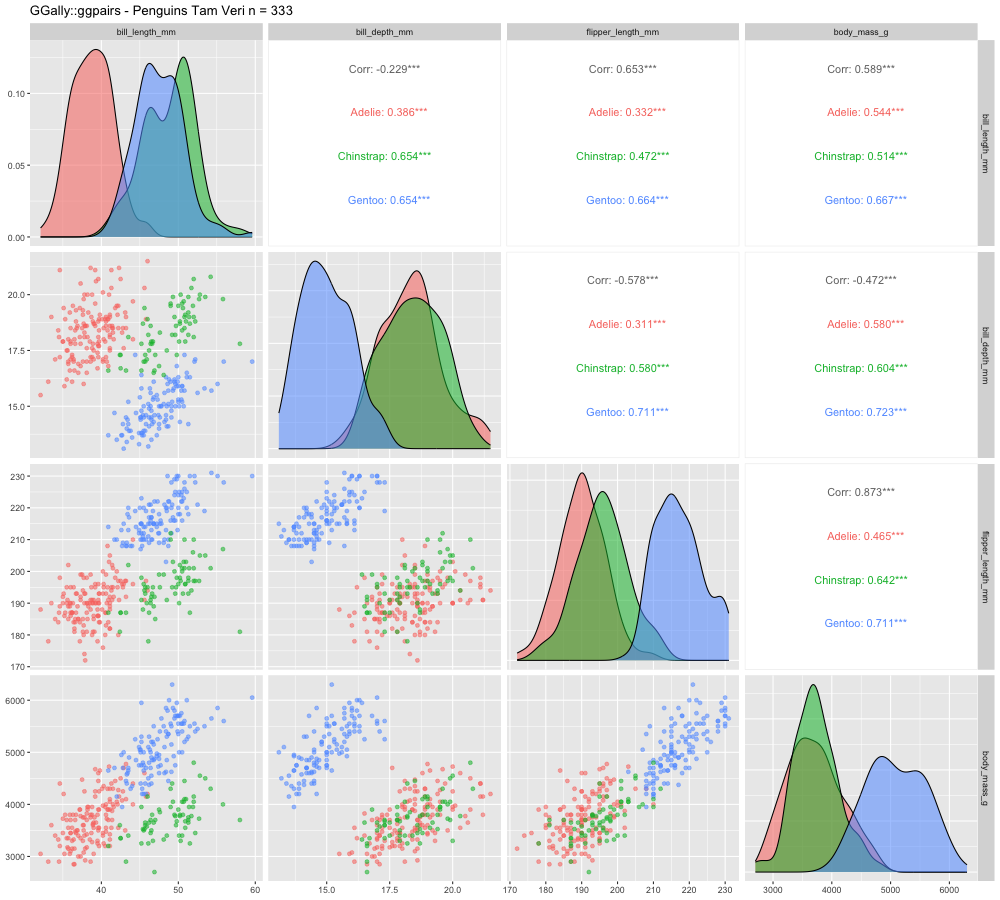

In [39]:
%%R -w 1000 -h 900
library(GGally)

ggpairs(penguins, columns = c("bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"),
        aes(color = species, alpha = 0.6),
        title = paste("GGally::ggpairs - Penguins Tam Veri n =", nrow(penguins)))

### 🔲 R 11 — FacetGrid Karşılığı: `facet_grid`

**Ne yapıyoruz?**
Python 15'in R karşılığı — `facet_grid(sex ~ class)` ile her sınıf x cinsiyet kombinasyonu için ayrı panel.

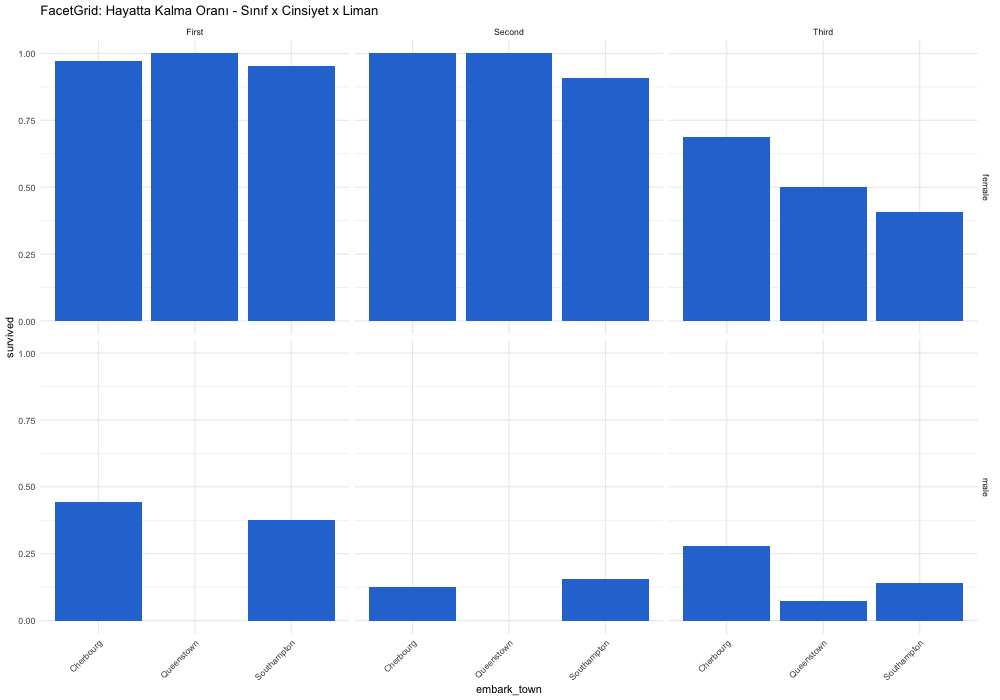

In [40]:
%%R -w 1000 -h 700
ggplot(titanic_r, aes(x = embark_town, y = survived)) +
  stat_summary(fun = mean, geom = "bar", fill = "#2a78d6") +
  facet_grid(sex ~ class) +
  ylim(0, 1) +
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 45, hjust = 1)) +
  ggtitle("FacetGrid: Hayatta Kalma Oranı - Sınıf x Cinsiyet x Liman")

### 🌡️ R 12 — Clustermap Karşılığı: `corrplot(order = "hclust")`

**Yeni R kavramı:** `corrplot`'un `order = "hclust"` parametresi, tam olarak Python 16'daki `sns.clustermap`'in yaptığı hiyerarşik kümelemeyi uygulayıp satır/sütunları yeniden sıralar; `addrect` ile kümeleri kutulara alabiliriz.

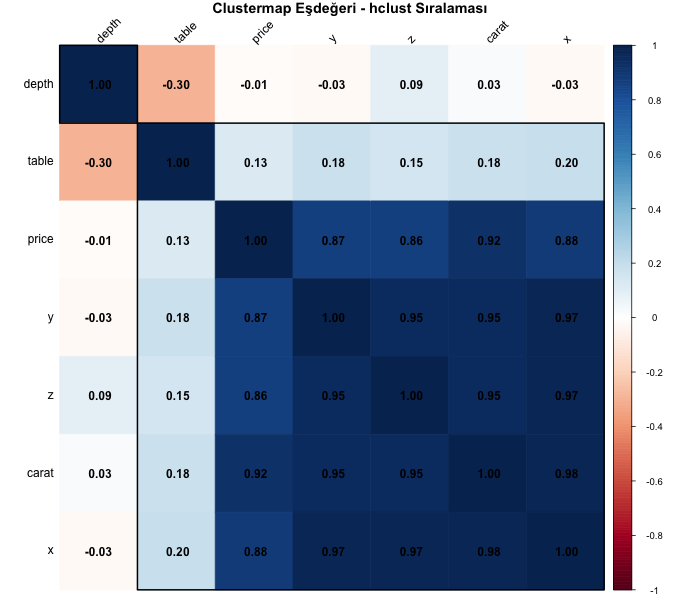

In [41]:
%%R -w 700 -h 600
corrplot(corr_mat_r, method = "color", order = "hclust", addrect = 2,
         addCoef.col = "black", tl.col = "black", tl.srt = 45,
         title = "Clustermap Eşdeğeri - hclust Sıralaması", mar = c(0, 0, 1, 0))

### 🫧 R 13 — Bubble Chart: `penguins`

**Ne yapıyoruz?**
Python 17'nin R karşılığı — `size` estetiğiyle (aesthetic) 3. boyutu, `color` ile 4. boyutu ekliyoruz.

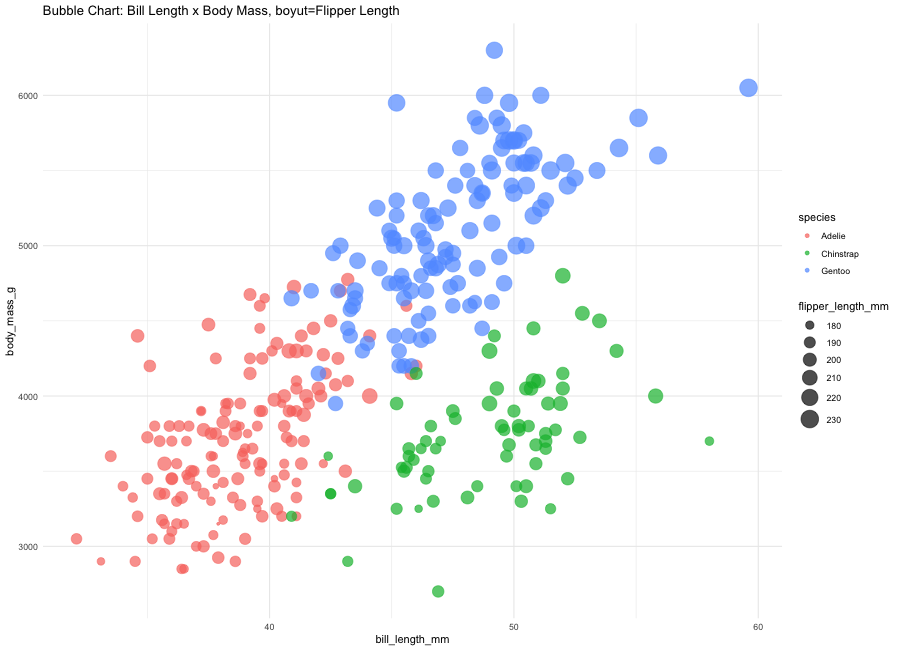

In [42]:
%%R -w 900 -h 650
ggplot(penguins, aes(x = bill_length_mm, y = body_mass_g, size = flipper_length_mm, color = species)) +
  geom_point(alpha = 0.7) +
  scale_size(range = c(1, 8)) +
  theme_minimal() +
  ggtitle("Bubble Chart: Bill Length x Body Mass, boyut=Flipper Length")

### 〰️ R 14 — Parallel Coordinates: `GGally::ggparcoord`

**Ne yapıyoruz?**
Python 18'in R karşılığı — `scale = "uniminmax"` parametresi otomatik olarak min-max ölçekleme yapıyor.

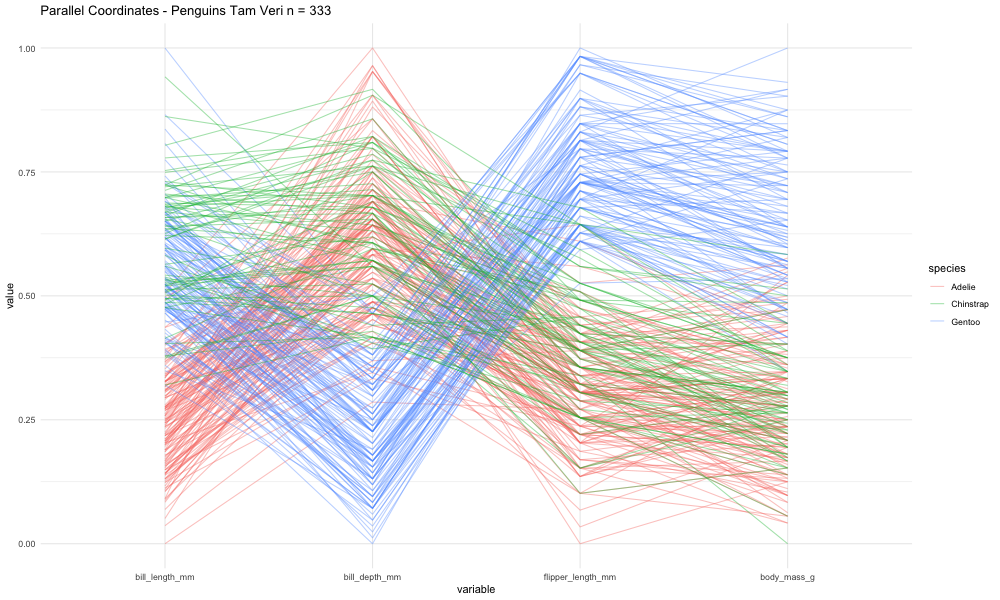

In [43]:
%%R -w 1000 -h 600
ggparcoord(penguins,
           columns = which(names(penguins) %in% c("bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g")),
           groupColumn = "species", scale = "uniminmax", alphaLines = 0.4) +
  theme_minimal() +
  ggtitle(paste("Parallel Coordinates - Penguins Tam Veri n =", nrow(penguins)))

---
# 🗄️ SQL Uygulaması (DuckDB): Grafik Olmadan "Grafik Okumak"

SQL çizim yapamaz — ama her grafiğin **arkasında yatan sayıları** hesaplayabilir. Bir histogramın aslında "eşit aralıklı gruplara göre `COUNT(*)`", bir hexbin'in aslında "2 boyutlu gruplara göre `COUNT(*)`", bir boxplot'un aslında "gruplanmış çeyrekler (`APPROX_QUANTILE`)", bir heatmap'in aslında "gruplanmış `CORR()`" olduğunu göreceğiz — bu, her grafiğin arkasındaki mantığı pekiştirmenin en iyi yollarından biri. (Pairplot, FacetGrid, clustermap, bubble chart, parallel coordinates gibi tamamen çok değişkenli/görsel kompozisyon gerektiren grafiklerin SQL'de anlamlı bir "sayısal karşılığı" yoktur — SQL'in gücünü, sayısal özet üretmede en net olduğu 5 örnekte gösteriyoruz.)

In [45]:
import duckdb
con = duckdb.connect()
con.register('diamonds_tbl', diamonds.astype({'cut': str, 'color': str, 'clarity': str}))
con.register('titanic_tbl', titanic.astype({c: str for c in ['sex', 'class', 'who', 'embark_town', 'alive', 'deck']}))
con.register('penguins_tbl', penguins)
print('DuckDB hazir ✓ (diamonds, titanic, penguins tabloları kayıtlı)')

DuckDB hazir ✓ (diamonds, titanic, penguins tabloları kayıtlı)


### 📊 SQL 1 — Histogram: Eşit Aralıklı Kutulara Göre `COUNT(*)` (`diamonds`, TAM VERİ)

**Ne yapıyoruz?**
Bir histogramın algoritmasını birebir SQL'e döküyoruz: `FLOOR(carat / bin_genisligi) * bin_genisligi` ile her gözlemi bir kutuya atıyoruz, `GROUP BY` + `COUNT(*)` ile Python 2'deki histogram'ın aynısını üretiyoruz.

   bucket_start     n
0           0.2  4203
1           0.3  8889
2           0.4  4582
3           0.5  6774
4           0.6  2714
5           0.7  3965
6           0.8   990
7           0.9  2763
8           1.0  7290
9           1.1  2615


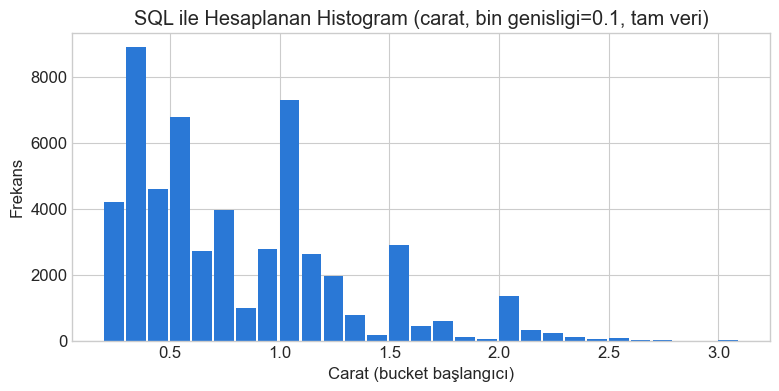

In [46]:
sql_hist = """
SELECT
    FLOOR(carat / 0.1) * 0.1 AS bucket_start,
    COUNT(*) AS n
FROM diamonds_tbl
WHERE carat <= 3
GROUP BY bucket_start
ORDER BY bucket_start;
"""

hist_df = con.execute(sql_hist).df()
print(hist_df.head(10))

plt.figure(figsize=(9, 4))
plt.bar(hist_df['bucket_start'], hist_df['n'], width=0.09, color='#2a78d6', align='edge')
plt.title('SQL ile Hesaplanan Histogram (carat, bin genisligi=0.1, tam veri)')
plt.xlabel('Carat (bucket başlangıcı)')
plt.ylabel('Frekans')
plt.show()

### 📶 SQL 2 — Bar / Count: Titanic Hayatta Kalma (TAM VERİ)

**Ne yapıyoruz?**
Python 7'deki count/bar plot'un sayısal karşılığı — `GROUP BY class, sex` ile hem sayım hem de ortalama hayatta kalma oranını (`AVG(survived)`) hesaplıyoruz.

In [47]:
sql_bar = """
SELECT
    class,
    sex,
    COUNT(*) AS n_yolcu,
    ROUND(AVG(survived), 3) AS hayatta_kalma_orani
FROM titanic_tbl
GROUP BY class, sex
ORDER BY class, sex;
"""

bar_df = con.execute(sql_bar).df()
print(bar_df)

    class     sex  n_yolcu  hayatta_kalma_orani
0   First  female       94                0.968
1   First    male      122                0.369
2  Second  female       76                0.921
3  Second    male      108                0.157
4   Third  female      144                0.500
5   Third    male      347                0.135


### 📦 SQL 3 — Boxplot İstatistikleri: `APPROX_QUANTILE` (`diamonds`, TAM VERİ)

**Ne yapıyoruz?**
DuckDB'nin `APPROX_QUANTILE` (T-Digest algoritmasıyla) fonksiyonunu kullanarak her `cut` kategorisi için Q1/medyan/Q3/IQR'ı ve Tukey'in 1.5×IQR sınırlarını doğrudan SQL'de hesaplıyoruz — Python 5'teki manuel boxplot istatistiklerinin SQL karşılığı.

In [48]:
sql_box = """
SELECT
    cut,
    COUNT(*) AS n,
    ROUND(APPROX_QUANTILE(price, 0.25), 0) AS q1,
    ROUND(APPROX_QUANTILE(price, 0.50), 0) AS median,
    ROUND(APPROX_QUANTILE(price, 0.75), 0) AS q3
FROM diamonds_tbl
GROUP BY cut
ORDER BY cut;
"""

box_df = con.execute(sql_box).df()
box_df['iqr'] = box_df['q3'] - box_df['q1']
box_df['lower_fence'] = box_df['q1'] - 1.5 * box_df['iqr']
box_df['upper_fence'] = box_df['q3'] + 1.5 * box_df['iqr']
print(box_df)

         cut      n    q1  median    q3   iqr  lower_fence  upper_fence
0       Fair   1610  2052    3281  5222  3170      -2703.0       9977.0
1       Good   4906  1157    3047  5033  3876      -4657.0      10847.0
2      Ideal  21551   878    1815  4682  3804      -4828.0      10388.0
3    Premium  13791  1047    3184  6302  5255      -6835.5      14184.5
4  Very Good  12082   916    2607  5369  4453      -5763.5      12048.5


### 🟧 SQL 4 — Hexbin / 2D Histogram Karşılığı: İki Eksende Birden `FLOOR` (`diamonds`, TAM VERİ)

**Ne yapıyoruz?**
Python 9'daki hexbin fikrini SQL'e taşıyoruz — hem `carat` hem `price` eksenini ayrı ayrı kutulara bölüp, iki boyutlu her (carat_bucket, price_bucket) hücresi için `COUNT(*)` hesaplıyoruz. Bu, bir hexbin/2D histogramın hücre değerlerinin **tam olarak** nasıl üretildiğini gösteriyor.

In [49]:
sql_2d = """
SELECT
    FLOOR(carat / 0.25) * 0.25 AS carat_bucket,
    FLOOR(price / 2000) * 2000 AS price_bucket,
    COUNT(*) AS n
FROM diamonds_tbl
GROUP BY carat_bucket, price_bucket
ORDER BY n DESC
LIMIT 15;
"""

grid_df = con.execute(sql_2d).df()
print("En yogun 15 (carat, price) kutusu:")
print(grid_df)

En yogun 15 (carat, price) kutusu:
    carat_bucket  price_bucket      n
0           0.25           0.0  17076
1           0.50           0.0   6450
2           1.00        4000.0   5812
3           0.50        2000.0   5773
4           0.75        2000.0   3341
5           1.00        6000.0   2667
6           0.75        4000.0   1356
7           1.00        2000.0   1178
8           1.00        8000.0   1011
9           1.50        8000.0    999
10          1.50       10000.0    939
11          1.50       12000.0    612
12          1.25        6000.0    606
13          0.00           0.0    573
14          1.50        6000.0    566


### 🟥 SQL 5 — Korelasyon: Türe Göre `CORR()` (`penguins`, TAM VERİ)

**Ne yapıyoruz?**
`species` kategorisine göre gruplanmış `bill_length_mm`-`body_mass_g` korelasyonunu hesaplıyoruz — genel (tüm veri) korelasyon ile alt-grup korelasyonlarının **farklı** çıkabileceğini gösteriyoruz (Bölüm 5.6'daki uyarı, Simpson Paradoksu'na benzer bir etki).

In [50]:
sql_corr_overall = con.execute(
    "SELECT ROUND(CORR(bill_length_mm, body_mass_g), 3) AS overall_corr FROM penguins_tbl"
).df()
print("Genel (tum veri) korelasyon:")
print(sql_corr_overall)

sql_corr_group = """
SELECT
    species,
    COUNT(*) AS n,
    ROUND(CORR(bill_length_mm, body_mass_g), 3) AS corr_bill_mass
FROM penguins_tbl
GROUP BY species
ORDER BY species;
"""
corr_group_df = con.execute(sql_corr_group).df()
print("\nTure gore gruplanmis korelasyon:")
print(corr_group_df)

print("\nYORUM: Alt gruplardaki korelasyonlar genel korelasyondan farkli olabiliyor -> species,")
print("bill_length-body_mass iliskisinin GUCUNU degistiren bir 'confounding'e benzer etki yapiyor.")

Genel (tum veri) korelasyon:
   overall_corr
0         0.589

Ture gore gruplanmis korelasyon:
     species    n  corr_bill_mass
0     Adelie  146           0.544
1  Chinstrap   68           0.514
2     Gentoo  119           0.667

YORUM: Alt gruplardaki korelasyonlar genel korelasyondan farkli olabiliyor -> species,
bill_length-body_mass iliskisinin GUCUNU degistiren bir 'confounding'e benzer etki yapiyor.


---
## ✏️ Egzersizler

Bu bölümdeki egzersizlerin **çözümü verilmemiştir** — amaç, yukarıdaki 19 grafik türünü kendi ellerinle uygulaman. Her egzersizin altında sadece boş bir hücre var; `diamonds`, `titanic`, `penguins` (Python) / `diamonds`, `titanic_r`, `penguins` (R) / `diamonds_tbl`, `titanic_tbl`, `penguins_tbl` (SQL) değişkenleri/tabloları zaten yukarıda hazır, doğrudan kullanabilirsin.

### **E1 (Python) — ECDF + Histogram.**
`penguins` veri setinde `body_mass_g` değişkeninin dağılımını `island` kategorisine göre (3 ada) hem histogram+KDE hem de ECDF ile çiz (Python 2 ve Python 4'teki gibi, **örneklem almadan, tam veriyle**). Hangi adadaki penguenlerin genel olarak daha ağır olduğunu, ECDF grafiğinden medyan noktalarını okuyarak yorumla.

In [ ]:
# Kodunu buraya yaz


### **E2 (Python) — Strip/Swarm + Boxplot + IQR.**
`titanic` veri setinde `age` değişkeninin `pclass`'a göre dağılımını hem swarm/strip plot hem de boxplot ile göster (Python 5 ve 6'daki gibi). Ardından her `pclass` için 1.5×IQR kuralıyla aykırı değer sayısını ve oranını **manuel olarak** (kod yazarak) hesapla — hangi sınıfta orantılı olarak en çok aykırı değer var?

In [ ]:
# Kodunu buraya yaz


### **E3 (Python) — Hexbin veya 2D KDE.**
`diamonds` veri setinde `depth` ile `table` arasındaki ilişkiyi (her ikisi de kesim oranı yüzdesi) **tam veriyle** (53.940 satır, örneklem almadan) hem hexbin hem de 2D KDE contour ile görselleştir (Python 9 ve 11'deki gibi). Bu iki değişken arasında Python 12'deki heatmap'te gördüğün zayıf korelasyonun görsel karşılığını nasıl yorumlarsın?

In [ ]:
# Kodunu buraya yaz


### **E4 (R) — FacetGrid / Small Multiples.**
`diamonds` veri setinde `price` histogramını `cut` kategorisine göre (5 panel) `facet_wrap(~ cut)` ile ayrıştır (Python 15 / R 11'deki `facet_grid` mantığının histogram versiyonu). Hangi kesim kategorisinin fiyat dağılımı en çok sağa çarpık görünüyor?

In [ ]:
%%R
# Kodunu buraya yaz


### **E5 (SQL) — Bar/Count + Korelasyon.**
DuckDB ile `penguins_tbl` üzerinde iki ayrı sorgu yaz: (a) `island` kategorisine göre penguen sayısını ve tür (`species`) dağılımını (`GROUP BY island, species`) veren bir sayım sorgusu, (b) her `island` için `flipper_length_mm` ile `body_mass_g` arasındaki `CORR()` değerini veren bir korelasyon sorgusu (SQL 5'teki gibi). Sonuçları `con.execute(...).df()` ile pandas DataFrame'e çevirip yorumla.

In [ ]:
# Kodunu buraya yaz


### **E6 (Python — Sentez).**
`penguins` (TAM VERİ) üzerinde, `bill_length_mm, bill_depth_mm, flipper_length_mm, body_mass_g` değişkenlerini kullanarak hem bir pairplot (Python 13'teki gibi) hem de bir parallel coordinates grafiği (Python 18'deki gibi) çiz, `hue`/`class_column` olarak `species` kullan. İki grafiğin de aynı sonuca ("hangi tür hangi değişkenlerde en net ayrışıyor") ulaşıp ulaşmadığını karşılaştır; gözlemini gerçek bir iş senaryosuna (örn. bir tür sınıflandırma modeli kurmadan önce hangi değişkenlerin en belirleyici olduğu) bağlayarak 2-3 cümle ile yorumla.

In [ ]:
# Kodunu buraya yaz


---
## 📚 Kaynaklar

| Kaynak | Bölüm | Notlar |
|---|---|---|
| [Titanic - Machine Learning from Disaster (Kaggle)](https://www.kaggle.com/competitions/titanic) | Veri Seti | Kullanılan 1. veri seti — Kaggle'ın en bilinen giriş yarışması |
| [Diamonds (Kaggle, shivam2503)](https://www.kaggle.com/datasets/shivam2503/diamonds) | Veri Seti | Kullanılan 2. veri seti — büyük N, çoğunlukla sayısal |
| [Palmer Archipelago Penguin Data (Kaggle, parulpandey)](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data) | Veri Seti | Kullanılan 3. veri seti — küçük, temiz, çok değişkenli EDA için |
| [palmerpenguins (CRAN / Allison Horst)](https://allisonhorst.github.io/palmerpenguins/) | R Paketi | `penguins` verisinin R'daki resmi kaynağı |
| [mwaskom/seaborn-data (GitHub)](https://github.com/mwaskom/seaborn-data) | Depo | seaborn `load_dataset()`'in çektiği veri deposu (titanic, diamonds, penguins) |
| [Fundamentals of Data Visualization — Claus O. Wilke](https://clauswilke.com/dataviz/) | Ch. 6–10 | Dağılım grafikleri (histogram, boxplot, violin, ECDF) ve çok değişkenli görselleştirme teorisi — ücretsiz online kitap |
| [Seaborn — Visualizing distributions of data](https://seaborn.pydata.org/tutorial/distributions.html) | Tutorial | `histplot`/`kdeplot`/`ecdfplot`/`rugplot`/`boxplot`/`violinplot` API |
| [Seaborn — Visualizing statistical relationships](https://seaborn.pydata.org/tutorial/relational.html) | Tutorial | `scatterplot`, hue/size ile boyut ekleme (bubble chart) |
| [Seaborn API — jointplot, pairplot, clustermap](https://seaborn.pydata.org/api.html) | API Referansı | Çok panelli/çok değişkenli figürler |
| [ggplot2 — diamonds dataset reference](https://ggplot2.tidyverse.org/reference/diamonds.html) | Docs | Kullanılan veri setinin resmi kaynağı (Python ve R'da ortak) |
| [GGally (CRAN)](https://cran.r-project.org/package=GGally) | R Paketi | `ggpairs` (pairplot) ve `ggparcoord` (parallel coordinates) |
| [ggbeeswarm (CRAN)](https://cran.r-project.org/package=ggbeeswarm) | R Paketi | `geom_beeswarm` — swarm plot karşılığı |
| [DuckDB — Aggregate Functions](https://duckdb.org/docs/current/sql/functions/aggregates) | Docs | `CORR`, `APPROX_QUANTILE`, `COVAR_POP` fonksiyon tanımları |
| [An Introduction to Statistical Learning](https://www.statlearning.com/) | Ch. 2–3 | EDA'nın istatistiksel öğrenme sürecindeki yeri, ücretsiz PDF |
| Bu proje — `covariance_correlation.ipynb` | Probability Lab 04b | Pearson/Spearman korelasyon teorisinin detaylı türetimi, Anscombe Dörtlüsü |
| Bu proje — `regression_diagnostics.ipynb` | Statistical Inference Lab 03 | Multicollinearity/VIF — Python 12/16'da değinilen çoklu-bağlantı konusunun devamı |
